In [ ]:
# %% [markdown]
# # LandslideMoE: Domain-Decoupled Mixture-of-Experts for Landslide Prediction
# **Architecture**: Faithful replication of EEGMoE (IEEE TNNLS) adapted for geospatial data.

# %% [markdown]
# ## 1. Setup & Installation
# %%
!pip install rasterio geopandas shapely fiona pyproj gdown netCDF4 xarray PyPDF2 -q

# %%
import os, glob, math, random, warnings, zipfile, shutil
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix)
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import rasterio
from rasterio.enums import Resampling
from rasterio.warp import reproject, calculate_default_transform
from rasterio.crs import CRS
from rasterio.transform import from_bounds
import gdown
warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# %% [markdown]
# ## 2. Download Actual Datasets
# %%
DRIVE_IDS = {
    "landslide_atlas": "1phUWEeg5m2DeJry13vpoN70WZW71iDfH",
    "wayanad_data": "1X42vJcGyTYTfOAzMgwKNRmGUKWyF4FJC",
    "wayanad_ref": "1VZFhK6X5VefdFup_rLC9PJpERi_XQBXW",
    "wayanad_impact": "1hZD3yG4Y6FeWs4fs0k9rwOGqvP_v_8gi",
    "puthumala_data": "1sQnIyzPhhsewpaCmYCyGw8GvoCKd1j60",
}
DATA_ROOT = "/content/landslide_data"
os.makedirs(DATA_ROOT, exist_ok=True)

def download_drive_file(file_id, output_path):
    """Download file from Google Drive with fallback methods."""
    if os.path.exists(output_path):
        sz = os.path.getsize(output_path)
        if sz > 10000:  # >10KB means it's likely a real file, not an HTML error page
            print(f"  Already exists: {output_path} ({sz/1024/1024:.1f}MB)")
            return
        else:
            os.remove(output_path)  # Remove tiny/corrupt files
    try:
        url = f"https://drive.google.com/uc?id={file_id}"
        gdown.download(url, output_path, quiet=False, fuzzy=True)
    except Exception as e1:
        print(f"  gdown failed: {e1}")
        print("  Trying fallback with requests session...")
        import requests
        session = requests.Session()
        r = session.get(f"https://drive.google.com/uc?export=download&id={file_id}", stream=True)
        # Check for confirmation token (large file warning)
        for key, value in r.cookies.items():
            if key.startswith('download_warning'):
                r = session.get(f"https://drive.google.com/uc?export=download&confirm={value}&id={file_id}", stream=True)
                break
        with open(output_path, 'wb') as f:
            for chunk in r.iter_content(32768):
                if chunk: f.write(chunk)
        print(f"  Fallback downloaded: {os.path.getsize(output_path)/1024/1024:.1f}MB")

def download_drive_folder(folder_id, output_dir):
    if os.path.exists(output_dir) and len(os.listdir(output_dir)) > 0:
        print(f"  Already exists: {output_dir}")
        return
    os.makedirs(output_dir, exist_ok=True)
    url = f"https://drive.google.com/drive/folders/{folder_id}"
    gdown.download_folder(url, output=output_dir, quiet=False)

# %%
print("=" * 60)
print("Downloading datasets from Google Drive...")
print("=" * 60)

atlas_dir = os.path.join(DATA_ROOT, "landslide_atlas")
os.makedirs(atlas_dir, exist_ok=True)
atlas_path = os.path.join(atlas_dir, "landslide_atlas.tif")
print("\n[1/5] Downloading LandslideAtlas (ground truth)...")
download_drive_file(DRIVE_IDS["landslide_atlas"], atlas_path)

# Verify atlas is a valid raster
atlas_valid = False
try:
    with rasterio.open(atlas_path) as src:
        print(f"  ✓ Atlas valid: {src.width}x{src.height}, CRS={src.crs}")
        atlas_valid = True
except Exception as e:
    print(f"  ✗ Atlas file not a valid raster: {e}")
    print("    This may be a shapefile/KML/GeoJSON. Checking file header...")
    with open(atlas_path, 'rb') as f:
        header = f.read(20)
    print(f"    First bytes: {header[:20]}")
    if header[:4] == b'PK\x03\x04':  # It's a zip (KMZ/shapefile bundle)
        print("    Detected as ZIP/KMZ archive. Extracting...")
        import zipfile
        with zipfile.ZipFile(atlas_path, 'r') as zf:
            zf.extractall(atlas_dir)
            print(f"    Extracted: {zf.namelist()}")

wayanad_dir = os.path.join(DATA_ROOT, "wayanad")
print("\n[2/5] Downloading Wayanad 2024 dataset...")
download_drive_folder(DRIVE_IDS["wayanad_data"], wayanad_dir)

wayanad_ref_dir = os.path.join(DATA_ROOT, "wayanad_ref")
print("\n[3/5] Downloading Wayanad reference data...")
download_drive_folder(DRIVE_IDS["wayanad_ref"], wayanad_ref_dir)

impact_dir = os.path.join(DATA_ROOT, "wayanad_impact")
os.makedirs(impact_dir, exist_ok=True)
impact_path = os.path.join(impact_dir, "impact_map.tif")
print("\n[4/5] Downloading Wayanad impact map...")
download_drive_file(DRIVE_IDS["wayanad_impact"], impact_path)

puthumala_dir = os.path.join(DATA_ROOT, "puthumala")
print("\n[5/5] Downloading Puthumala 2019 dataset...")
download_drive_folder(DRIVE_IDS["puthumala_data"], puthumala_dir)

print("\n✓ All downloads complete!")

# %% [markdown]
# ## 2b. Extract Knowledge from PDF Documents
# %%
def extract_pdf_text(pdf_path):
    """Extract text from a PDF file."""
    try:
        from PyPDF2 import PdfReader
        reader = PdfReader(pdf_path)
        text = ""
        for page in reader.pages:
            t = page.extract_text()
            if t: text += t + "\n"
        return text.strip()
    except Exception as e:
        print(f"  PDF extraction error ({os.path.basename(pdf_path)}): {e}")
        return ""

def chunk_text(text, chunk_size=200, overlap=50):
    """Split text into overlapping word-chunks for embedding."""
    words = text.split()
    chunks = []
    for i in range(0, len(words), chunk_size - overlap):
        chunk = ' '.join(words[i:i+chunk_size])
        if len(chunk.split()) > 20:  # Skip tiny fragments
            chunks.append(chunk)
    return chunks

# Find and extract ALL PDFs in data directory
print("\n" + "="*60 + "\nExtracting knowledge from PDF documents...\n" + "="*60)
pdf_knowledge_texts = []
for root, dirs, files in os.walk(DATA_ROOT):
    for f in files:
        fpath = os.path.join(root, f)
        # Check if file is actually a PDF (by content, not just extension)
        try:
            with open(fpath, 'rb') as fh:
                if fh.read(5) == b'%PDF-':
                    text = extract_pdf_text(fpath)
                    if len(text) > 100:
                        pdf_knowledge_texts.append(text)
                        print(f"  ✓ Extracted: {os.path.basename(fpath)} ({len(text):,} chars)")
        except: pass

if pdf_knowledge_texts:
    all_knowledge_text = "\n\n".join(pdf_knowledge_texts)
    knowledge_chunks = chunk_text(all_knowledge_text, chunk_size=200, overlap=50)
    print(f"\n  Total: {len(pdf_knowledge_texts)} PDFs → {len(all_knowledge_text):,} chars → {len(knowledge_chunks)} chunks")
else:
    all_knowledge_text = ""
    knowledge_chunks = []
    print("  No PDFs found.")

# %% [markdown]
# ## 3. Extract Zipped Sub-Datasets & Explore Structure
# %%
# Extract any zip files found in the data directories
for root, dirs, files in os.walk(DATA_ROOT):
    for f in files:
        if f.endswith('.zip') and 'landslide_atlas' not in root:
            zpath = os.path.join(root, f)
            extract_to = os.path.join(root, f.replace('.zip', ''))
            if not os.path.exists(extract_to):
                os.makedirs(extract_to, exist_ok=True)
                try:
                    with zipfile.ZipFile(zpath, 'r') as zf:
                        zf.extractall(extract_to)
                    print(f"Extracted: {zpath}")
                except zipfile.BadZipFile:
                    print(f"Not a valid zip: {zpath}")

# Show tree
def show_tree(path, prefix="", max_depth=3, depth=0):
    if depth >= max_depth: return
    entries = sorted(os.listdir(path)) if os.path.isdir(path) else []
    for i, e in enumerate(entries):
        fp = os.path.join(path, e)
        conn = "└── " if i == len(entries)-1 else "├── "
        sz = f" ({os.path.getsize(fp)/1024/1024:.1f}MB)" if os.path.isfile(fp) and os.path.getsize(fp) > 1024 else ""
        print(f"{prefix}{conn}{e}{sz}")
        if os.path.isdir(fp):
            show_tree(fp, prefix + ("    " if i == len(entries)-1 else "│   "), max_depth, depth+1)

print("\nData structure:")
show_tree(DATA_ROOT)

# %% [markdown]
# ## 4. CRS-Aware Data Loading Pipeline
# %%
def find_rasters(directory, extensions=('.tif', '.tiff', '.img')):
    rasters = []
    if not os.path.exists(directory): return rasters
    for root, dirs, files in os.walk(directory):
        for f in sorted(files):
            if f.lower().endswith(extensions) and not f.startswith('.'):
                rasters.append(os.path.join(root, f))
    return rasters

def get_bounds_in_4326(raster_path):
    """Get raster bounds in EPSG:4326 for universal overlap comparison."""
    with rasterio.open(raster_path) as src:
        if src.crs is None:
            return None
        if src.crs.to_epsg() == 4326:
            return src.bounds
        dst_crs = CRS.from_epsg(4326)
        transform, width, height = calculate_default_transform(
            src.crs, dst_crs, src.width, src.height, *src.bounds)
        left = transform.c
        top = transform.f
        right = left + transform.a * width
        bottom = top + transform.e * height
        from rasterio.coords import BoundingBox
        return BoundingBox(left=min(left,right), bottom=min(top,bottom),
                          right=max(left,right), top=max(top,bottom))

def bounds_overlap(b1, b2):
    if b1 is None or b2 is None: return False
    return (b1.left < b2.right and b1.right > b2.left and
            b1.bottom < b2.top and b1.top > b2.bottom)

def load_and_resample(src_path, dst_crs, dst_transform, dst_width, dst_height):
    """Load raster and reproject to destination grid."""
    with rasterio.open(src_path) as src:
        data = np.empty((src.count, dst_height, dst_width), dtype=np.float32)
        for b in range(src.count):
            reproject(
                source=rasterio.band(src, b+1),
                destination=data[b],
                src_transform=src.transform, src_crs=src.crs,
                dst_transform=dst_transform, dst_crs=dst_crs,
                resampling=Resampling.bilinear)
    return data

def load_netcdf_as_band(nc_path, target_bounds_4326, dst_crs, dst_transform, dst_w, dst_h):
    """Load NetCDF rainfall data and resample to target grid."""
    try:
        import xarray as xr
        ds = xr.open_dataset(nc_path)
        # Find the rainfall variable
        rain_var = None
        for v in ds.data_vars:
            if any(k in v.lower() for k in ['rain', 'precip', 'rf', 'tp']):
                rain_var = v; break
        if rain_var is None:
            rain_var = list(ds.data_vars)[0]
        data = ds[rain_var].values
        if data.ndim == 3:  # (time, lat, lon) -> sum over time
            data = np.nansum(data, axis=0).astype(np.float32)
        elif data.ndim > 3:
            data = np.nansum(data, axis=tuple(range(data.ndim-2))).astype(np.float32)
        # Get coords
        lat = ds.coords.get('lat', ds.coords.get('latitude', ds.coords.get('LAT')))
        lon = ds.coords.get('lon', ds.coords.get('longitude', ds.coords.get('LON')))
        if lat is None or lon is None:
            for c in ds.coords:
                if 'lat' in c.lower(): lat = ds.coords[c]
                if 'lon' in c.lower(): lon = ds.coords[c]
        lat_vals, lon_vals = lat.values, lon.values
        # Create in-memory raster and reproject
        src_transform = from_bounds(
            lon_vals.min(), lat_vals.min(), lon_vals.max(), lat_vals.max(),
            data.shape[1], data.shape[0])
        out = np.empty((1, dst_h, dst_w), dtype=np.float32)
        reproject(
            source=data, destination=out[0],
            src_transform=src_transform, src_crs=CRS.from_epsg(4326),
            dst_transform=dst_transform, dst_crs=dst_crs,
            resampling=Resampling.bilinear)
        ds.close()
        return out
    except Exception as e:
        print(f"    NetCDF load error: {e}")
        return None

def classify_raster(filepath):
    name = os.path.basename(filepath).lower()
    parent = os.path.basename(os.path.dirname(filepath)).lower()
    combined = f"{parent}/{name}"
    if any(k in combined for k in ['sentinel-1','sentinel1','s1','sar','vv','vh','backscatter','sigma','coherence']):
        return 'SAR'
    elif any(k in combined for k in ['sentinel-2','sentinel2','s2','b01','b02','b03','b04','b05','b06','b07','b08','b09','b11','b12','b8a','ndvi','optical','multispectral']):
        return 'Optical'
    elif any(k in combined for k in ['rain','precip','imd','chirps']):
        return 'Hydromet'
    elif any(k in combined for k in ['soil','moisture','smap','sm_']):
        return 'Soil'
    elif any(k in combined for k in ['dem','elevation','slope','aspect','srtm','copernicus_dem']):
        return 'DEM'
    elif any(k in combined for k in ['atlas','label','ground_truth','gt','mask','landslide','impact','inventory']):
        return 'Label'
    return 'Other'

def normalize_bands(data):
    for c in range(data.shape[0]):
        band = data[c]
        valid = band[~np.isnan(band)]
        if len(valid) > 0:
            p2, p98 = np.percentile(valid, [2, 98])
            if p98 - p2 > 1e-8:
                data[c] = np.clip((band - p2) / (p98 - p2), 0, 1)
            else:
                data[c] = 0.0
        else:
            data[c] = 0.0
    return np.nan_to_num(data, 0.0)

# %%
def aggregate_domain_bands(all_bands, channel_info, domain_ids, domain_name, max_bands=3):
    """Aggregate bands from a domain into summary statistics (mean, max, std) if too many."""
    indices = [i for i, info in enumerate(channel_info) if info.startswith(domain_name + ':')]
    if len(indices) <= max_bands:
        return all_bands, channel_info, domain_ids  # No aggregation needed

    domain_data = np.stack([all_bands[i] for i in indices], axis=0)  # (N, H, W)
    agg_mean = np.nanmean(domain_data, axis=0)
    agg_max = np.nanmax(domain_data, axis=0)
    agg_std = np.nanstd(domain_data, axis=0)

    # Remove original bands and insert aggregated ones
    keep_mask = [i for i in range(len(all_bands)) if i not in indices]
    new_bands = [all_bands[i] for i in keep_mask]
    new_info = [channel_info[i] for i in keep_mask]
    new_dom = [domain_ids[i] for i in keep_mask]

    dom_id = domain_ids[indices[0]]
    for arr, suffix in [(agg_mean, 'mean'), (agg_max, 'max'), (agg_std, 'std')]:
        new_bands.append(arr)
        new_info.append(f"{domain_name}:aggregated:{suffix}")
        new_dom.append(dom_id)

    print(f"  Aggregated {len(indices)} {domain_name} bands → 3 summary bands (mean/max/std)")
    return new_bands, new_info, new_dom

def generate_slope_from_dem(stacked, channel_info, ref_transform):
    """Generate slope from DEM band for pseudo-label creation."""
    dem_idx = None
    for i, info in enumerate(channel_info):
        if 'DEM' in info or 'dem' in info.lower():
            dem_idx = i; break
    if dem_idx is None:
        return None

    dem = stacked[dem_idx]
    # Compute slope using numpy gradient
    px_size = abs(ref_transform.a)  # pixel size in CRS units (meters for UTM)
    if px_size < 0.01: px_size = 30.0  # fallback if in degrees
    dy, dx = np.gradient(dem, px_size)
    slope = np.degrees(np.arctan(np.sqrt(dx**2 + dy**2)))
    return slope

def generate_pseudo_labels(stacked, channel_info, ref_transform, site_name):
    """Generate landslide susceptibility pseudo-labels using geomorphological indicators."""
    H, W = stacked.shape[1], stacked.shape[2]

    # 1. Slope from DEM (steep slopes > 15° are landslide-prone)
    slope = generate_slope_from_dem(stacked, channel_info, ref_transform)
    slope_risk = np.zeros((H, W), dtype=np.float32)
    if slope is not None:
        slope_risk = np.clip((slope - 15.0) / 30.0, 0, 1)  # Normalize: 15°-45° → 0-1
        print(f"  DEM slope: mean={np.nanmean(slope):.1f}°, max={np.nanmax(slope):.1f}°")

    # 2. High soil moisture (saturated soil increases risk)
    sm_risk = np.zeros((H, W), dtype=np.float32)
    for i, info in enumerate(channel_info):
        if 'Soil' in info and 'mean' in info:
            sm = stacked[i]
            sm_risk = np.clip((sm - np.nanpercentile(sm[sm > 0], 70)) /
                             (np.nanpercentile(sm[sm > 0], 95) - np.nanpercentile(sm[sm > 0], 70) + 1e-8), 0, 1)
            print(f"  Soil moisture risk computed")
            break

    # 3. Vegetation loss (low NDVI from optical bands indicates exposed soil)
    ndvi_risk = np.zeros((H, W), dtype=np.float32)
    nir_idx, red_idx = None, None
    for i, info in enumerate(channel_info):
        if 'B08' in info and nir_idx is None: nir_idx = i  # Sentinel-2 Band 8 (NIR)
        if 'B04' in info and red_idx is None: red_idx = i   # Sentinel-2 Band 4 (Red)
    if nir_idx is not None and red_idx is not None:
        nir, red = stacked[nir_idx].astype(np.float64), stacked[red_idx].astype(np.float64)
        ndvi = (nir - red) / (nir + red + 1e-8)
        ndvi_risk = np.clip(0.3 - ndvi, 0, 0.6) / 0.6  # Low NDVI (<0.3) = high risk
        print(f"  NDVI risk: bare soil pixels = {np.mean(ndvi < 0.2)*100:.1f}%")

    # 4. High rainfall increases risk
    rain_risk = np.zeros((H, W), dtype=np.float32)
    for i, info in enumerate(channel_info):
        if 'Hydromet' in info:
            r = stacked[i]
            valid = r[r > 0]
            if len(valid) > 0:
                rain_risk = np.clip((r - np.percentile(valid, 60)) /
                                   (np.percentile(valid, 95) - np.percentile(valid, 60) + 1e-8), 0, 1)
            print(f"  Rainfall risk computed")
            break

    # Combine multi-factor susceptibility
    combined = 0.35 * slope_risk + 0.25 * sm_risk + 0.25 * ndvi_risk + 0.15 * rain_risk
    threshold = np.percentile(combined[combined > 0], 85)  # Top 15% as landslide-prone
    labels = (combined > threshold).astype(np.float32)

    pct = np.mean(labels > 0) * 100
    print(f"  Pseudo-labels: {pct:.1f}% landslide pixels (threshold={threshold:.3f})")
    return labels

def load_site_data(site_dir, label_paths, site_name="Site"):
    """Load all rasters for a site using CRS-aware alignment."""
    print(f"\n{'='*60}\nLoading: {site_name}\n{'='*60}")

    all_rasters = find_rasters(site_dir)
    nc_files = []
    for root, dirs, files in os.walk(site_dir):
        for f in files:
            if f.lower().endswith('.nc'):
                nc_files.append(os.path.join(root, f))

    classified = {}
    for r in all_rasters:
        cls = classify_raster(r)
        if cls != 'Label':
            classified.setdefault(cls, []).append(r)

    print(f"Found rasters:")
    for domain, files in classified.items():
        print(f"  {domain}: {len(files)} files")
    if nc_files:
        print(f"  NetCDF (Rainfall): {len(nc_files)} files")

    # Pick reference: prefer SAR > Optical > DEM
    ref_path = None
    for priority_domain in ['SAR', 'Optical', 'DEM', 'Soil', 'Other']:
        for r in classified.get(priority_domain, []):
            try:
                with rasterio.open(r) as src:
                    if src.crs is not None:
                        ref_path = r; break
            except: continue
        if ref_path: break

    if ref_path is None:
        print("ERROR: No valid georeferenced rasters found!")
        return None, None, [], [], None

    with rasterio.open(ref_path) as src:
        ref_crs = src.crs
        ref_transform = src.transform
        ref_w, ref_h = src.width, src.height
    ref_bounds_4326 = get_bounds_in_4326(ref_path)
    print(f"Reference: {os.path.basename(ref_path)} ({ref_w}x{ref_h}, CRS={ref_crs})")

    # Stack all bands with CRS-aware overlap
    all_bands, channel_info, domain_ids = [], [], []
    domain_map = {'SAR': 0, 'Optical': 1, 'Hydromet': 2, 'Soil': 3, 'DEM': 3, 'Other': 1}

    for domain in ['SAR', 'Optical', 'DEM', 'Soil', 'Other']:
        for rpath in classified.get(domain, []):
            try:
                r_bounds_4326 = get_bounds_in_4326(rpath)
                if not bounds_overlap(ref_bounds_4326, r_bounds_4326):
                    continue
                data = load_and_resample(rpath, ref_crs, ref_transform, ref_w, ref_h)
                for b in range(data.shape[0]):
                    all_bands.append(data[b])
                    channel_info.append(f"{domain}:{os.path.basename(rpath)}:B{b+1}")
                    domain_ids.append(domain_map.get(domain, 1))
                print(f"  ✓ {os.path.basename(rpath)} ({data.shape[0]} bands) [{domain}]")
            except Exception as e:
                print(f"  ✗ Error {os.path.basename(rpath)}: {e}")

    # Load NetCDF rainfall
    for nc_path in nc_files:
        nc_data = load_netcdf_as_band(nc_path, ref_bounds_4326, ref_crs, ref_transform, ref_w, ref_h)
        if nc_data is not None:
            all_bands.append(nc_data[0])
            channel_info.append(f"Hydromet:{os.path.basename(nc_path)}:rain")
            domain_ids.append(2)
            print(f"  ✓ {os.path.basename(nc_path)} (rainfall) [Hydromet]")

    if len(all_bands) == 0:
        print("ERROR: No bands loaded!")
        return None, None, [], [], None

    # Aggregate Soil Moisture (201 bands → 3: mean/max/std)
    all_bands, channel_info, domain_ids = aggregate_domain_bands(
        all_bands, channel_info, domain_ids, 'Soil', max_bands=5)

    stacked = normalize_bands(np.stack(all_bands, axis=0))
    print(f"\nFinal stacked: {stacked.shape} ({len(channel_info)} channels)")
    for i, info in enumerate(channel_info):
        print(f"  Ch{i:2d}: {info} [domain={domain_ids[i]}]")

    # Try loading raster labels
    labels = np.zeros((ref_h, ref_w), dtype=np.float32)
    label_loaded = False
    for lpath in label_paths:
        if not os.path.exists(lpath): continue
        # Skip files that are PDFs
        try:
            with open(lpath, 'rb') as f:
                if f.read(5) == b'%PDF-':
                    continue
        except: pass
        try:
            l_bounds_4326 = get_bounds_in_4326(lpath)
            if not bounds_overlap(ref_bounds_4326, l_bounds_4326):
                continue
            ldata = load_and_resample(lpath, ref_crs, ref_transform, ref_w, ref_h)
            labels = np.maximum(labels, (ldata[0] > 0).astype(np.float32))
            label_loaded = True
            print(f"  ✓ Label loaded: {os.path.basename(lpath)}")
        except Exception as e:
            pass  # Skip silently — we know atlas/impact are PDFs

    if not label_loaded:
        print("  No raster labels available. Generating physics-based pseudo-labels...")
        labels = generate_pseudo_labels(stacked, channel_info, ref_transform, site_name)

    print(f"Label stats: {np.mean(labels>0)*100:.2f}% landslide pixels")
    return stacked, labels, channel_info, domain_ids, ref_transform

# %% [markdown]
# ## 5. Config & Knowledge Encoder
# %%
class Config:
    PATCH_SIZE = 16; IMG_SIZE = 64
    IN_CHANNELS = None; NUM_PATCHES = (IMG_SIZE // PATCH_SIZE) ** 2
    NUM_DOMAINS = 5; DOMAIN_MAP = None  # domain 4 = Knowledge/Text
    D_MODEL = 256; N_HEADS = 8; N_LAYERS = 6; D_FF = 512; DROPOUT = 0.1
    N_SHARED_EXPERTS = 2; N_SPECIFIC_EXPERTS = 6; TOP_K = 2
    LOAD_BALANCE_ALPHA = 0.01; MASK_RATIO = 0.4
    PRETRAIN_EPOCHS = 50; PRETRAIN_LR = 1e-4
    FINETUNE_EPOCHS = 30; FINETUNE_LR = 5e-5
    BATCH_SIZE = 32; NUM_CLASSES = 1
    N_KNOWLEDGE_TOKENS = 8  # Number of knowledge tokens injected into encoder
    VOCAB_SIZE = 10000       # Simple word-level vocabulary size
cfg = Config()

# %%
class TextKnowledgeEncoder(nn.Module):
    """
    Encodes text chunks from PDFs into d_model-dimensional knowledge tokens.
    These tokens are prepended to spatial tokens and routed through domain-4
    experts in the MoE, allowing experts to specialize in paper knowledge.

    Uses a simple learned word embedding + positional encoding + mean pooling.
    """
    def __init__(self, vocab_size, d_model, n_tokens, max_words=200):
        super().__init__()
        self.n_tokens = n_tokens
        self.max_words = max_words
        self.word_embed = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos_embed = nn.Parameter(torch.randn(1, max_words, d_model) * 0.02)
        self.proj = nn.Sequential(
            nn.Linear(d_model, d_model), nn.GELU(),
            nn.Linear(d_model, d_model * n_tokens)
        )
        self.norm = nn.LayerNorm(d_model)

    def forward(self, token_ids):
        # token_ids: (B, max_words) word indices
        B = token_ids.shape[0]
        x = self.word_embed(token_ids)  # (B, max_words, d_model)
        x = x + self.pos_embed[:, :x.shape[1], :]
        # Mean pool over words
        mask = (token_ids > 0).float().unsqueeze(-1)  # (B, max_words, 1)
        x = (x * mask).sum(dim=1) / (mask.sum(dim=1) + 1e-8)  # (B, d_model)
        # Project to n_tokens knowledge tokens
        x = self.proj(x)  # (B, d_model * n_tokens)
        x = x.view(B, self.n_tokens, -1)  # (B, n_tokens, d_model)
        return self.norm(x)

# Build vocabulary from extracted knowledge
def build_vocab(texts, max_vocab=10000):
    word_freq = {}
    for text in texts:
        for w in text.lower().split():
            w = ''.join(c for c in w if c.isalnum())
            if w: word_freq[w] = word_freq.get(w, 0) + 1
    sorted_words = sorted(word_freq.items(), key=lambda x: -x[1])[:max_vocab-2]
    vocab = {'<PAD>': 0, '<UNK>': 1}
    for w, _ in sorted_words:
        vocab[w] = len(vocab)
    return vocab

def tokenize_chunk(chunk, vocab, max_len=200):
    words = chunk.lower().split()
    ids = [vocab.get(''.join(c for c in w if c.isalnum()), 1) for w in words[:max_len]]
    ids += [0] * (max_len - len(ids))  # pad
    return ids

# Build vocab and tokenize chunks
if knowledge_chunks:
    knowledge_vocab = build_vocab(knowledge_chunks, cfg.VOCAB_SIZE)
    knowledge_token_ids = np.array([tokenize_chunk(c, knowledge_vocab) for c in knowledge_chunks], dtype=np.int64)
    print(f"Knowledge vocab: {len(knowledge_vocab)} words, {knowledge_token_ids.shape[0]} chunks")
else:
    knowledge_vocab = {'<PAD>': 0, '<UNK>': 1}
    knowledge_token_ids = np.zeros((1, 200), dtype=np.int64)  # dummy
    print("No knowledge chunks; using empty knowledge.")

# %% [markdown]
# ## 6. Create Tiles & Datasets
# %%
def create_tiles(data, labels, tile_size=64, stride=32, min_valid=0.5):
    C, H, W = data.shape
    tiles_x, tiles_y = [], []
    for i in range(0, H - tile_size + 1, stride):
        for j in range(0, W - tile_size + 1, stride):
            tile = data[:, i:i+tile_size, j:j+tile_size]
            if np.mean(np.any(tile != 0, axis=0)) < min_valid: continue
            ls_ratio = np.mean(labels[i:i+tile_size, j:j+tile_size] > 0)
            tiles_x.append(tile)
            tiles_y.append(1.0 if ls_ratio > 0.05 else 0.0)
    return np.array(tiles_x, np.float32), np.array(tiles_y, np.float32)

class LandslideDataset(Dataset):
    def __init__(self, X, y, domain_ids_list, knowledge_ids=None):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
        self.domain_ids = torch.LongTensor(domain_ids_list)
        # Sample random knowledge chunks per batch item for diversity
        if knowledge_ids is not None and len(knowledge_ids) > 0:
            self.knowledge_ids = torch.LongTensor(knowledge_ids)
        else:
            self.knowledge_ids = torch.zeros(1, 200, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, idx):
        # Sample a random knowledge chunk for this item
        k_idx = idx % len(self.knowledge_ids)
        return self.X[idx], self.y[idx], self.domain_ids, self.knowledge_ids[k_idx]

# %% [markdown]
# ## 7. Load All Sites
# %%
# Collect label candidates (even if they're PDFs, we check format inside load_site_data)
label_files = []
for root, dirs, files in os.walk(DATA_ROOT):
    for f in files:
        fp = os.path.join(root, f)
        if classify_raster(fp) == 'Label':
            label_files.append(fp)
print(f"Label candidates: {[os.path.basename(f) for f in label_files]}")

wayanad_data, wayanad_labels, wayanad_ch, wayanad_dom, wayanad_tf = load_site_data(
    wayanad_dir, label_files, "Wayanad 2024")
puthumala_data, puthumala_labels, puthumala_ch, puthumala_dom, puthumala_tf = load_site_data(
    puthumala_dir, label_files, "Puthumala 2019")

# %%
# Match channel counts by padding smaller site to the larger
max_ch = 0
if wayanad_data is not None: max_ch = max(max_ch, wayanad_data.shape[0])
if puthumala_data is not None: max_ch = max(max_ch, puthumala_data.shape[0])

def pad_channels(data, domains, target_ch):
    C = data.shape[0]
    if C < target_ch:
        pad = np.zeros((target_ch - C, data.shape[1], data.shape[2]), np.float32)
        data = np.concatenate([data, pad], axis=0)
        domains = domains + [3] * (target_ch - C)
    return data, domains

# Use tighter stride (16px) for maximum data utilization (75% overlap)
TILE_STRIDE = 16

wayanad_data_p, wayanad_dom_p = pad_channels(wayanad_data, wayanad_dom, max_ch)
wx, wy = create_tiles(wayanad_data_p, wayanad_labels, cfg.IMG_SIZE, TILE_STRIDE)
print(f"\nWayanad: {wx.shape[0]} tiles ({np.mean(wy)*100:.1f}% positive)")

puthumala_data_p, puthumala_dom_p = pad_channels(puthumala_data, puthumala_dom, max_ch)
px, py = create_tiles(puthumala_data_p, puthumala_labels, cfg.IMG_SIZE, TILE_STRIDE)
print(f"Puthumala: {px.shape[0]} tiles ({np.mean(py)*100:.1f}% positive)")

# %%
cfg.IN_CHANNELS = max_ch
cfg.DOMAIN_MAP = {i: wayanad_dom_p[i] if i < len(wayanad_dom_p) else 3
                  for i in range(cfg.IN_CHANNELS)}
dom_tensor = [cfg.DOMAIN_MAP.get(c, 0) for c in range(cfg.IN_CHANNELS)]

# Wayanad: 85% Train, 15% Val
n_w = len(wx); idx_w = np.random.permutation(n_w); tr_end = int(0.85 * n_w)
train_ds = LandslideDataset(wx[idx_w[:tr_end]], wy[idx_w[:tr_end]], dom_tensor, knowledge_token_ids)
val_ds = LandslideDataset(wx[idx_w[tr_end:]], wy[idx_w[tr_end:]], dom_tensor, knowledge_token_ids)

# Puthumala: entire site as held-out benchmark
puthumala_ds = LandslideDataset(px, py, dom_tensor, knowledge_token_ids)

# ALL data for self-supervised pretraining (no labels needed)
pretrain_X = np.concatenate([wx, px])
pretrain_y = np.concatenate([wy, py])
pretrain_ds = LandslideDataset(pretrain_X, pretrain_y, dom_tensor, knowledge_token_ids)

train_loader = DataLoader(train_ds, batch_size=cfg.BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=cfg.BATCH_SIZE, shuffle=False)
puthumala_loader = DataLoader(puthumala_ds, batch_size=cfg.BATCH_SIZE, shuffle=False)
pretrain_loader = DataLoader(pretrain_ds, batch_size=cfg.BATCH_SIZE, shuffle=True, drop_last=True)

print(f"\n{'='*60}\nDATA SPLIT\n{'='*60}")
print(f"Channels: {cfg.IN_CHANNELS} | Tile size: {cfg.IMG_SIZE} | Stride: {TILE_STRIDE}")
print(f"Pretrain (ALL):         {len(pretrain_ds)} tiles")
print(f"Wayanad Train:          {len(train_ds)} tiles ({np.mean(wy[idx_w[:tr_end]])*100:.1f}% pos)")
print(f"Wayanad Val:            {len(val_ds)} tiles ({np.mean(wy[idx_w[tr_end:]])*100:.1f}% pos)")
print(f"Puthumala Benchmark:    {len(puthumala_ds)} tiles ({np.mean(py)*100:.1f}% pos)")

# %% [markdown]
# ## 8. EEGMoE Architecture
# ### 8.1 Patch Embedding
# %%
class DualEncoderTokenization(nn.Module):
    """
    EEGMoE Tokenization: Projects 4D input to 2D tokens via Spatial & Spectral encoders.
    Original EEG 4D: (Batch, Channels, Spatial, Frequency)
    Geospatial 4D: (Batch, Channels, Height, Width)

    The Spatial Encoder processes height/width (spatial domain).
    The Spectral Encoder processes channels (representing spectral/frequency bands).
    """
    def __init__(self, in_channels, d_model, patch_size, img_size, num_domains):
        super().__init__()
        self.num_patches = (img_size // patch_size) ** 2

        # Spatial Encoder: 2D Conv over Height/Width
        self.spatial_encoder = nn.Conv2d(in_channels, d_model // 2, kernel_size=patch_size, stride=patch_size)

        # Spectral Encoder: 1D Conv over Channels (treated as frequency/spectral bands)
        # We reshape to (B*NumPatches, 1, In_Channels) to run a 1D conv over the channel dimension
        # and then project it to (d_model // 2)
        self.spectral_encoder = nn.Sequential(
            nn.Linear(in_channels, d_model // 2),
            nn.GELU(),
            nn.Linear(d_model // 2, d_model // 2)
        )

        # Positional and domain embeddings add to the combined 2D tokens
        self.pos_embed = nn.Parameter(torch.randn(1, self.num_patches, d_model) * 0.02)
        self.domain_embed = nn.Embedding(num_domains, d_model)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x, domain_ids):
        # x: (B, C, H, W) -> 4D tensor
        B, C, H, W = x.shape

        # 1. Spatial Encoding (extracts 2D spatial features)
        spatial_tokens = self.spatial_encoder(x)             # (B, d_model//2, H/P, W/P)
        spatial_tokens = spatial_tokens.flatten(2).transpose(1, 2)  # (B, N, d_model//2)

        # 2. Spectral Encoding (extracts 1D channel/band features for each patch)
        # Average pooling over each patch to get a single spectral vector per patch
        N_H, N_W = H // self.spatial_encoder.kernel_size[0], W // self.spatial_encoder.kernel_size[1]
        x_patches = x.view(B, C, N_H, self.spatial_encoder.kernel_size[0], N_W, self.spatial_encoder.kernel_size[1])
        x_patches = x_patches.permute(0, 2, 4, 1, 3, 5).contiguous().view(B, N_H * N_W, C, -1)
        spectral_avg = x_patches.mean(dim=-1)                # (B, N, C)
        spectral_tokens = self.spectral_encoder(spectral_avg) # (B, N, d_model//2)

        # 3. Concatenate to form final 2D tokens (B, N, d_model)
        tokens = torch.cat([spatial_tokens, spectral_tokens], dim=-1)

        # 4. Add Embeddings
        tokens = tokens + self.pos_embed
        d_emb = self.domain_embed(domain_ids).mean(dim=1, keepdim=True)
        tokens = tokens + d_emb.expand_as(tokens)

        return self.norm(tokens)

# Alias to map seamlessly into our existing codebase without renaming everything
PatchEmbedding = DualEncoderTokenization

# %% [markdown]
# ### 8.2 Domain-Decoupled MoE Block
# %%
class Expert(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(d_model, d_ff), nn.GELU(), nn.Dropout(dropout),
                                 nn.Linear(d_ff, d_model), nn.Dropout(dropout))
    def forward(self, x): return self.net(x)

class SharedExpertGroup(nn.Module):
    """Soft routing: ALL experts contribute, weighted by gate."""
    def __init__(self, n_experts, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.experts = nn.ModuleList([Expert(d_model, d_ff, dropout) for _ in range(n_experts)])
        self.gate = nn.Linear(d_model, n_experts)
    def forward(self, x):
        gate_scores = F.softmax(self.gate(x), dim=-1)
        output = torch.zeros_like(x)
        for i, exp in enumerate(self.experts):
            output = output + gate_scores[:,:,i].unsqueeze(-1) * exp(x)
        return output, gate_scores

class SpecificExpertGroup(nn.Module):
    """Top-K routing: only K experts activated per token."""
    def __init__(self, n_experts, d_model, d_ff, top_k=2, dropout=0.1):
        super().__init__()
        self.n_experts = n_experts; self.top_k = top_k
        self.experts = nn.ModuleList([Expert(d_model, d_ff, dropout) for _ in range(n_experts)])
        self.gate = nn.Linear(d_model, n_experts)
    def forward(self, x):
        B, N, D = x.shape
        gate_logits = self.gate(x)
        topk_logits, topk_idx = gate_logits.topk(self.top_k, dim=-1)
        topk_scores = F.softmax(topk_logits, dim=-1)
        output = torch.zeros(B, N, D, device=x.device, dtype=x.dtype)
        for k in range(self.top_k):
            eidx = topk_idx[:,:,k]
            w = topk_scores[:,:,k].unsqueeze(-1)
            for i in range(self.n_experts):
                mask = (eidx == i)
                if mask.any():
                    inp = x[mask]
                    eout = self.experts[i](inp)
                    buf = torch.zeros(B, N, D, device=x.device, dtype=eout.dtype)
                    buf[mask] = eout
                    output = output + w * buf
        gate_scores = F.softmax(gate_logits, dim=-1)
        return output, gate_scores, topk_idx

class DomainDecoupledMoEBlock(nn.Module):
    """Output = Shared + Specific + LoadBalanceLoss."""
    def __init__(self, d_model, d_ff, n_shared, n_specific, top_k, dropout=0.1):
        super().__init__()
        self.shared = SharedExpertGroup(n_shared, d_model, d_ff, dropout)
        self.specific = SpecificExpertGroup(n_specific, d_model, d_ff, top_k, dropout)
    def forward(self, x):
        s_out, _ = self.shared(x)
        sp_out, sp_gates, topk_idx = self.specific(x)
        lb = self._lb_loss(sp_gates, topk_idx)
        return s_out + sp_out, lb
    def _lb_loss(self, gates, topk_idx):
        n = self.specific.n_experts
        B, N, K = topk_idx.shape
        flat = topk_idx.reshape(-1)
        counts = torch.zeros(n, device=gates.device)
        for i in range(n): counts[i] = (flat == i).float().sum()
        f = counts / (B*N*K + 1e-8)
        P = gates.mean(dim=[0,1])
        return n * (f * P).sum()

# %% [markdown]
# ### 8.3 Encoder
# %%
class EEGMoEEncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, n_shared, n_specific, top_k, dropout=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model); self.norm2 = nn.LayerNorm(d_model)
        self.moe = DomainDecoupledMoEBlock(d_model, d_ff, n_shared, n_specific, top_k, dropout)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x):
        res = x; x = self.norm1(x); att, _ = self.attn(x, x, x); x = res + self.dropout(att)
        res = x; moe_out, lb = self.moe(self.norm2(x)); x = res + self.dropout(moe_out)
        return x, lb

class EEGMoEEncoder(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, n_layers, n_shared, n_specific, top_k, dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList([EEGMoEEncoderLayer(
            d_model, n_heads, d_ff, n_shared, n_specific, top_k, dropout) for _ in range(n_layers)])
        self.norm = nn.LayerNorm(d_model)
    def forward(self, x):
        total_lb = 0.0
        for layer in self.layers: x, lb = layer(x); total_lb += lb
        return self.norm(x), total_lb

# %% [markdown]
# ### 8.4 MAE Pretraining & Classification
# %%
class LandslideMoE_MAE(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.patch_embed = PatchEmbedding(cfg.IN_CHANNELS, cfg.D_MODEL, cfg.PATCH_SIZE, cfg.IMG_SIZE, cfg.NUM_DOMAINS)
        self.knowledge_embed = TextKnowledgeEncoder(cfg.VOCAB_SIZE, cfg.D_MODEL, cfg.N_KNOWLEDGE_TOKENS)
        self.encoder = EEGMoEEncoder(cfg.D_MODEL, cfg.N_HEADS, cfg.D_FF, cfg.N_LAYERS,
                                     cfg.N_SHARED_EXPERTS, cfg.N_SPECIFIC_EXPERTS, cfg.TOP_K, cfg.DROPOUT)
        self.mask_token = nn.Parameter(torch.randn(1, 1, cfg.D_MODEL) * 0.02)
        self.decoder = nn.Sequential(nn.Linear(cfg.D_MODEL, cfg.D_FF), nn.GELU(),
                                     nn.Linear(cfg.D_FF, cfg.IN_CHANNELS * cfg.PATCH_SIZE**2))
    def forward(self, x, domain_ids, knowledge_ids):
        B = x.shape[0]; tokens = self.patch_embed(x, domain_ids); N_spatial = tokens.shape[1]

        # Add Knowledge Tokens
        k_tokens = self.knowledge_embed(knowledge_ids)  # (B, N_K, D)
        k_domain = torch.full((B, k_tokens.shape[1]), 4, dtype=torch.long, device=x.device)  # Domain 4
        k_tokens = k_tokens + self.patch_embed.domain_embed(k_domain)

        # Combine (Knowledge + Spatial)
        tokens = torch.cat([k_tokens, tokens], dim=1)
        N = tokens.shape[1]

        target = x.unfold(2, self.cfg.PATCH_SIZE, self.cfg.PATCH_SIZE).unfold(3, self.cfg.PATCH_SIZE, self.cfg.PATCH_SIZE)
        target = target.contiguous().view(B, self.cfg.IN_CHANNELS, -1, self.cfg.PATCH_SIZE, self.cfg.PATCH_SIZE)
        target = target.permute(0,2,1,3,4).contiguous().view(B, N_spatial, -1)

        # Masking (only mask spatial tokens, keep knowledge visible)
        n_mask = int(N_spatial * self.cfg.MASK_RATIO)
        ids = torch.argsort(torch.rand(B, N_spatial, device=x.device), dim=1)
        mask_ids, vis_ids = ids[:, :n_mask], ids[:, n_mask:]

        # Visible tokens = Knowledge + Visible Spatial
        vis_spatial_tok = torch.gather(tokens[:, k_tokens.shape[1]:], 1, vis_ids.unsqueeze(-1).expand(-1, -1, self.cfg.D_MODEL))
        vis_tok = torch.cat([k_tokens, vis_spatial_tok], dim=1)

        enc, lb = self.encoder(vis_tok)

        # Restore full sequence for decoding
        full_spatial = self.mask_token.expand(B, N_spatial, -1).clone()
        # Spatial encodings start after knowledge tokens
        enc_spatial = enc[:, k_tokens.shape[1]:]
        full_spatial.scatter_(1, vis_ids.unsqueeze(-1).expand(-1, -1, self.cfg.D_MODEL), enc_spatial)

        pred = self.decoder(full_spatial)
        mt = torch.gather(target, 1, mask_ids.unsqueeze(-1).expand(-1, -1, target.shape[-1]))
        mp = torch.gather(pred, 1, mask_ids.unsqueeze(-1).expand(-1, -1, pred.shape[-1]))
        recon = F.mse_loss(mp, mt)
        return recon + self.cfg.LOAD_BALANCE_ALPHA * lb, recon, lb
        full = self.mask_token.expand(B, N, -1).clone()
        full.scatter_(1, vis_ids.unsqueeze(-1).expand(-1,-1,self.cfg.D_MODEL), enc)
        pred = self.decoder(full)
        mt = torch.gather(target, 1, mask_ids.unsqueeze(-1).expand(-1,-1,target.shape[-1]))
        mp = torch.gather(pred, 1, mask_ids.unsqueeze(-1).expand(-1,-1,pred.shape[-1]))
        recon = F.mse_loss(mp, mt)
        return recon + self.cfg.LOAD_BALANCE_ALPHA * lb, recon, lb

class LandslideMoE_Classifier(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.patch_embed = PatchEmbedding(cfg.IN_CHANNELS, cfg.D_MODEL, cfg.PATCH_SIZE, cfg.IMG_SIZE, cfg.NUM_DOMAINS)
        self.knowledge_embed = TextKnowledgeEncoder(cfg.VOCAB_SIZE, cfg.D_MODEL, cfg.N_KNOWLEDGE_TOKENS)
        self.encoder = EEGMoEEncoder(cfg.D_MODEL, cfg.N_HEADS, cfg.D_FF, cfg.N_LAYERS,
                                     cfg.N_SHARED_EXPERTS, cfg.N_SPECIFIC_EXPERTS, cfg.TOP_K, cfg.DROPOUT)
        self.classifier = nn.Sequential(nn.LayerNorm(cfg.D_MODEL), nn.Linear(cfg.D_MODEL, cfg.D_MODEL//2),
                                        nn.GELU(), nn.Dropout(cfg.DROPOUT), nn.Linear(cfg.D_MODEL//2, 1))
    def load_pretrained(self, mae):
        self.patch_embed.load_state_dict(mae.patch_embed.state_dict())
        self.knowledge_embed.load_state_dict(mae.knowledge_embed.state_dict())
        self.encoder.load_state_dict(mae.encoder.state_dict())
        print("✓ Loaded pretrained visual encoder and knowledge encoder weights.")
    def forward(self, x, domain_ids, knowledge_ids):
        B = x.shape[0]
        tokens = self.patch_embed(x, domain_ids)

        # Add Knowledge Tokens
        k_tokens = self.knowledge_embed(knowledge_ids)
        k_domain = torch.full((B, k_tokens.shape[1]), 4, dtype=torch.long, device=x.device)
        k_tokens = k_tokens + self.patch_embed.domain_embed(k_domain)

        # Combine and encode
        tokens = torch.cat([k_tokens, tokens], dim=1)
        enc, lb = self.encoder(tokens)

        # Global average pooling over all tokens (knowledge + spatial)
        return self.classifier(enc.mean(dim=1)).squeeze(-1), lb

# %% [markdown]
# ## 9. Training
# %%
def pretrain(model, loader, cfg):
    model = model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg.PRETRAIN_LR, weight_decay=0.05)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, cfg.PRETRAIN_EPOCHS)
    print("="*60 + "\nPhase 1: Self-Supervised Knowledge-Aware Pretraining\n" + "="*60)
    for ep in range(cfg.PRETRAIN_EPOCHS):
        model.train(); tl, tr_, tlb = 0,0,0
        for bx, _, did, kid in loader:
            bx, did, kid = bx.to(device), did.to(device), kid.to(device)
            opt.zero_grad()
            loss, rl, lb = model(bx, did, kid)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); tl += loss.item(); tr_ += rl.item(); tlb += lb.item()
        sched.step(); n = len(loader)
        if (ep+1) % 5 == 0 or ep == 0:
            print(f"  Epoch [{ep+1}/{cfg.PRETRAIN_EPOCHS}] Loss:{tl/n:.4f} Recon:{tr_/n:.4f} LB:{tlb/n:.4f}")
    return model

def finetune(model, train_loader, val_loader, cfg):
    model = model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg.FINETUNE_LR, weight_decay=0.01)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, cfg.FINETUNE_EPOCHS)
    crit = nn.BCEWithLogitsLoss()
    print("\n" + "="*60 + "\nPhase 2: Supervised Fine-Tuning\n" + "="*60)
    best_f1, best_state = 0.0, None
    hist = {'train_loss':[], 'val_loss':[], 'val_f1':[]}
    for ep in range(cfg.FINETUNE_EPOCHS):
        model.train(); tl = 0
        for bx, by, did, kid in train_loader:
            bx, by, did, kid = bx.to(device), by.to(device), did.to(device), kid.to(device)
            opt.zero_grad()
            logits, lb = model(bx, did, kid)
            loss = crit(logits, by) + cfg.LOAD_BALANCE_ALPHA * lb
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); tl += loss.item()
        sched.step()
        model.eval(); vl = 0; preds, labs, probs = [],[],[]
        with torch.no_grad():
            for bx, by, did, kid in val_loader:
                bx, by, did, kid = bx.to(device), by.to(device), did.to(device), kid.to(device)
                logits, lb = model(bx, did, kid)
                vl += (crit(logits, by) + cfg.LOAD_BALANCE_ALPHA * lb).item()
                p = torch.sigmoid(logits).cpu().numpy()
                probs.extend(p); preds.extend((p>0.5).astype(float)); labs.extend(by.cpu().numpy())
        preds, labs, probs = np.array(preds), np.array(labs), np.array(probs)
        f1 = f1_score(labs, preds, zero_division=0)
        hist['train_loss'].append(tl/len(train_loader))
        hist['val_loss'].append(vl/max(1,len(val_loader)))
        hist['val_f1'].append(f1)
        if f1 > best_f1:
            best_f1 = f1; best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        if (ep+1) % 5 == 0 or ep == 0:
            acc = accuracy_score(labs, preds)
            try: auc = roc_auc_score(labs, probs)
            except: auc = float('nan')
            print(f"  Epoch [{ep+1}/{cfg.FINETUNE_EPOCHS}] TrL:{tl/len(train_loader):.4f} "
                  f"VL:{vl/max(1,len(val_loader)):.4f} Acc:{acc:.4f} F1:{f1:.4f} AUC:{auc:.4f}")
    if best_state: model.load_state_dict(best_state)
    print(f"\n  Best Val F1: {best_f1:.4f}")
    return model, hist

# %% [markdown]
# ## 10. Evaluation & Visualization
# %%
def evaluate(model, loader, label="TEST"):
    model.eval(); preds, labs, probs = [],[],[]
    with torch.no_grad():
        for bx, by, did in loader:
            bx, did = bx.to(device), did.to(device)
            logits, _ = model(bx, did)
            p = torch.sigmoid(logits).cpu().numpy()
            probs.extend(p); preds.extend((p>0.5).astype(float)); labs.extend(by.numpy())
    preds, labs, probs = np.array(preds), np.array(labs), np.array(probs)
    acc = accuracy_score(labs, preds)
    prec = precision_score(labs, preds, zero_division=0)
    rec = recall_score(labs, preds, zero_division=0)
    f1 = f1_score(labs, preds, zero_division=0)
    try: auc = roc_auc_score(labs, probs)
    except: auc = float('nan')
    cm = confusion_matrix(labs, preds)
    print(f"\n{'='*60}\n{label} RESULTS\n{'='*60}")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1:        {f1:.4f}")
    print(f"  AUC-ROC:   {auc:.4f}" if not np.isnan(auc) else "  AUC-ROC:   N/A")
    print(f"\n  CM:\n{cm}")
    return {'acc': acc, 'prec': prec, 'rec': rec, 'f1': f1, 'auc': auc}

def plot_history(hist):
    fig, (a1,a2) = plt.subplots(1,2,figsize=(14,5))
    a1.plot(hist['train_loss'], label='Train'); a1.plot(hist['val_loss'], label='Val')
    a1.set_xlabel('Epoch'); a1.set_ylabel('Loss'); a1.legend(); a1.grid(True); a1.set_title('Loss')
    a2.plot(hist['val_f1'], label='F1', color='green')
    a2.set_xlabel('Epoch'); a2.set_ylabel('F1'); a2.legend(); a2.grid(True); a2.set_title('Val F1')
    plt.tight_layout(); plt.savefig('/content/training_history.png', dpi=150); plt.show()

def generate_map(model, data, dom_ids, cfg, name="Site"):
    model.eval(); C, H, W = data.shape
    prob = np.zeros((H,W), np.float32); cnt = np.zeros((H,W), np.float32)
    ts, st = cfg.IMG_SIZE, cfg.IMG_SIZE//2
    did = torch.LongTensor(dom_ids).unsqueeze(0).to(device)
    with torch.no_grad():
        for i in range(0, H-ts+1, st):
            for j in range(0, W-ts+1, st):
                t = torch.FloatTensor(data[:, i:i+ts, j:j+ts]).unsqueeze(0).to(device)
                logits, _ = model(t, did); p = torch.sigmoid(logits).cpu().item()
                prob[i:i+ts, j:j+ts] += p; cnt[i:i+ts, j:j+ts] += 1
    cnt[cnt==0] = 1; prob /= cnt
    fig, ax = plt.subplots(figsize=(12,10))
    cmap = mcolors.LinearSegmentedColormap.from_list('ls', ['#2d6a4f','#95d5b2','#ffd166','#ef476f','#d00000'])
    im = ax.imshow(prob, cmap=cmap, vmin=0, vmax=1)
    ax.set_title(f'Susceptibility Map — {name}', fontsize=16, fontweight='bold')
    plt.colorbar(im, ax=ax, label='Landslide Probability', shrink=0.8)
    plt.tight_layout(); plt.savefig(f'/content/susceptibility_{name.lower().replace(" ","_")}.png', dpi=200); plt.show()
    return prob

# %% [markdown]
# ## 11. Main Pipeline
# %%
print("="*60 + "\nLandslideMoE Pipeline\n" + "="*60)

# Phase 1: Pretrain on ALL data (Wayanad + Puthumala, self-supervised)
mae = LandslideMoE_MAE(cfg)
print(f"MAE: {sum(p.numel() for p in mae.parameters()):,} params")
mae = pretrain(mae, pretrain_loader, cfg)

# Phase 2: Fine-tune on Wayanad (train/val)
classifier = LandslideMoE_Classifier(cfg)
classifier.load_pretrained(mae)
print(f"Classifier: {sum(p.numel() for p in classifier.parameters()):,} params")
classifier, hist = finetune(classifier, train_loader, val_loader, cfg)

# Phase 3: Evaluate
print("\n" + "#"*60)
print("# BENCHMARK RESULTS")
print("#"*60)

wayanad_results = evaluate(classifier, val_loader, "WAYANAD 2024 (Validation)")
puthumala_results = evaluate(classifier, puthumala_loader, "PUTHUMALA 2019 (Benchmark)")

print(f"\n{'='*70}")
print(f"{'BENCHMARK SUMMARY TABLE':^70}")
print(f"{'='*70}")
print(f"{'Metric':<15} {'Wayanad Val':>15} {'Puthumala 2019':>15}")
print(f"{'-'*45}")
for m in ['acc', 'prec', 'rec', 'f1', 'auc']:
    w = wayanad_results[m]; p = puthumala_results[m]
    print(f"{m.upper():<15} {w:>15.4f} {p:>15.4f}")
print(f"{'='*70}")

plot_history(hist)

# %% [markdown]
# ## 12. Susceptibility Maps
# %%
if wayanad_data is not None:
    generate_map(classifier, wayanad_data_p, dom_tensor, cfg, "Wayanad 2024")

if puthumala_data is not None:
    generate_map(classifier, puthumala_data_p, dom_tensor, cfg, "Puthumala 2019")

print("\n✓ Pipeline Complete!")



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 5.5 MB/s eta 0:00:00
Using device: cuda

[1/5] Downloading LandslideAtlas (ground truth)...
  Already exists: /content/landslide_data/landslide_atlas/landslide_atlas.tif (10.6MB)
  ✗ Atlas file not a valid raster: '/content/landslide_data/landslide_atlas/landslide_atlas.tif' not recognized as being in a supported file format.
    This may be a shapefile/KML/GeoJSON. Checking file header...
    First bytes: b'%PDF-1.7\r\n%\xb5\xb5\xb5\xb5\r\n1 0'

[2/5] Downloading Wayanad 2024 dataset...
  Already exists: /content/landslide_data/wayanad

[3/5] Downloading Wayanad reference data...
  Already exists: /content/landslide_data/wayanad_ref

[4/5] Downloading Wayanad impact map...
  Already exists: /content/landslide_data/wayanad_impact/impact_map.tif (16.3MB)

[5/5] Downloading Puthumala 2019 dataset...
  Already exists: /content/landslide_data/puthumala

✓ All downloads complete!

Extracting knowledge from PDF documents...
  ✓ Extra

Using device: cuda

[1/5] Downloading LandslideAtlas (ground truth)...
  Already exists: /content/landslide_data/landslide_atlas/landslide_atlas.tif (10.6MB)
  ✗ Atlas file not a valid raster: '/content/landslide_data/landslide_atlas/landslide_atlas.tif' not recognized as being in a supported file format.
    This may be a shapefile/KML/GeoJSON. Checking file header...
    First bytes: b'%PDF-1.7\r\n%\xb5\xb5\xb5\xb5\r\n1 0'

[2/5] Downloading Wayanad 2024 dataset...
  Already exists: /content/landslide_data/wayanad

[3/5] Downloading Wayanad reference data...
  Already exists: /content/landslide_data/wayanad_ref

[4/5] Downloading Wayanad impact map...
  Already exists: /content/landslide_data/wayanad_impact/impact_map.tif (16.3MB)

[5/5] Downloading Puthumala 2019 dataset...
  Already exists: /content/landslide_data/puthumala

✓ All downloads complete!

Extracting knowledge from PDF documents...
  ✓ Extracted: landslide_atlas.zip (71,925 chars)
  ✓ Extracted: landslide_atlas.tif (71,

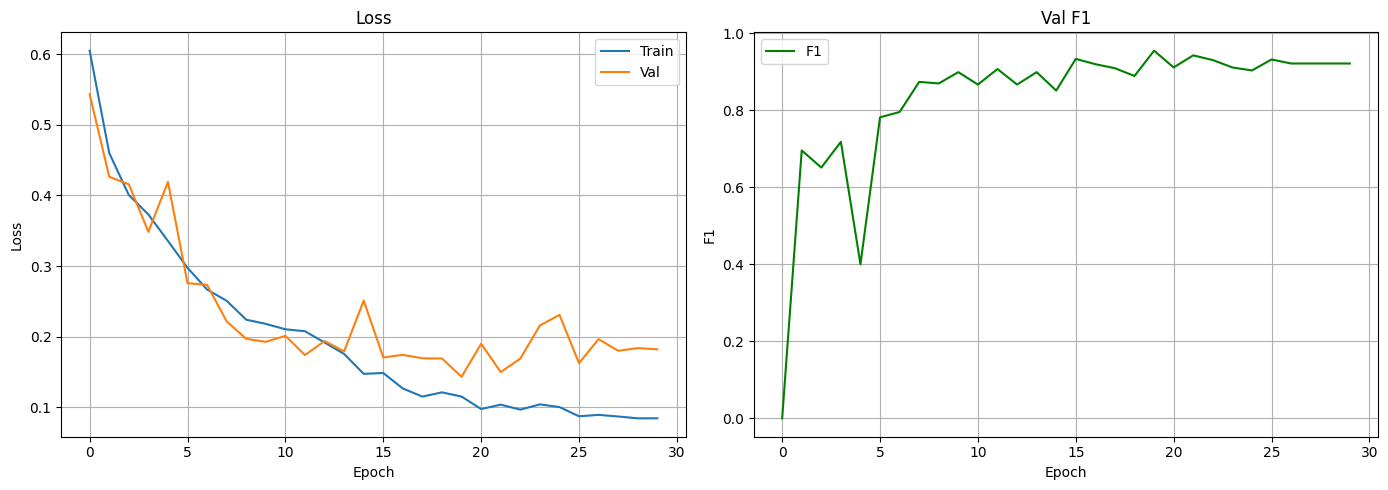

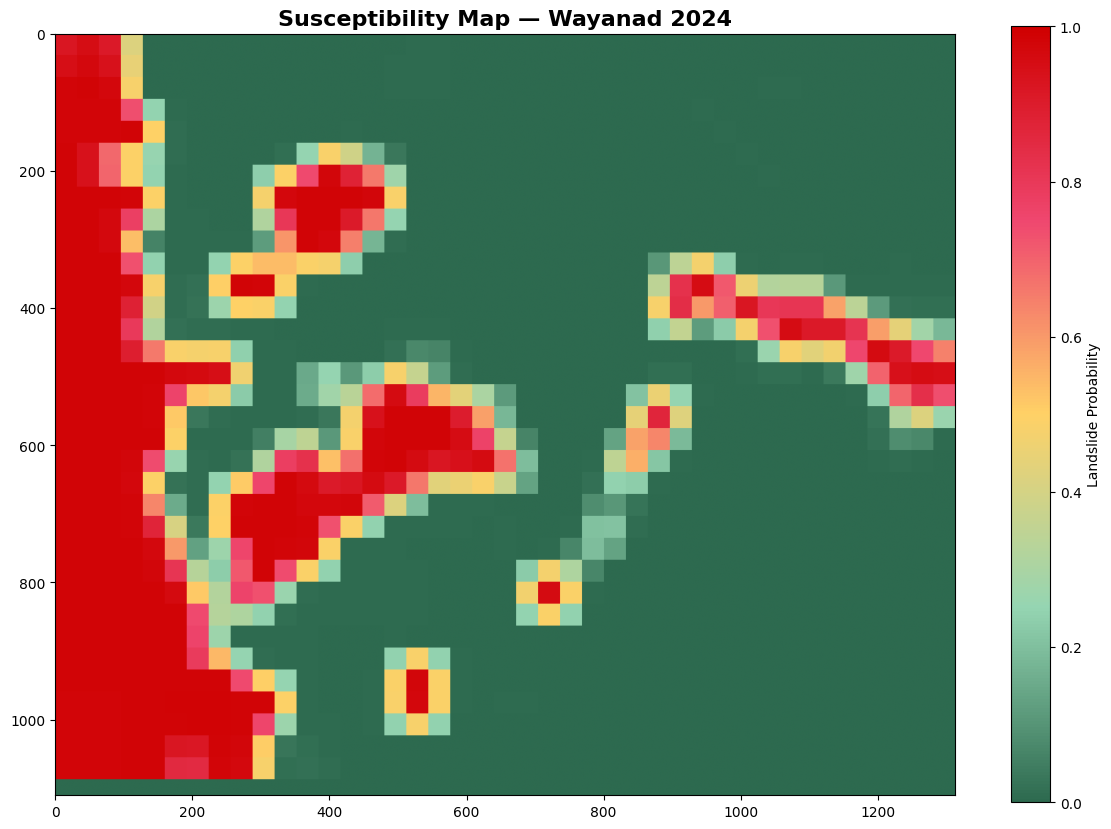

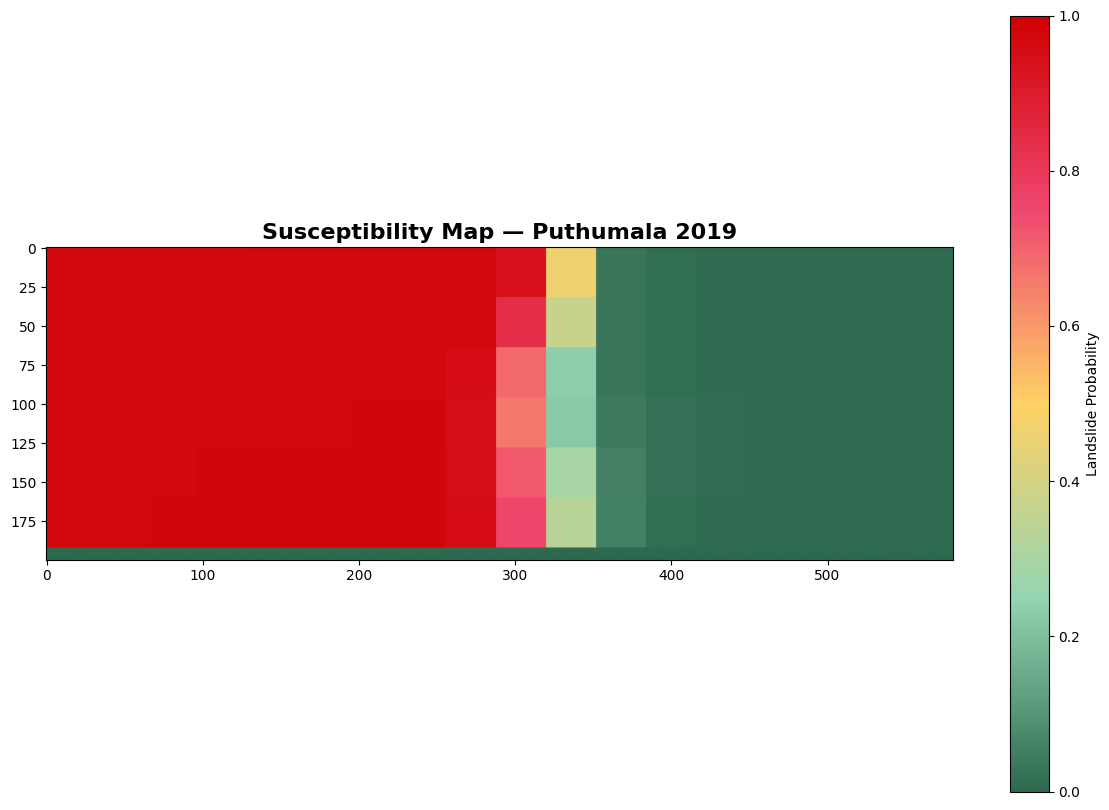


✓ Pipeline Complete!


In [ ]:
# %% [markdown]
# # LandslideMoE: Domain-Decoupled Mixture-of-Experts for Landslide Prediction
# **Architecture**: Faithful replication of EEGMoE (IEEE TNNLS) adapted for geospatial data.

# %% [markdown]
# ## 1. Setup & Installation
# %%
!pip install rasterio geopandas shapely fiona pyproj gdown netCDF4 xarray PyPDF2 -q

# %%
import os, glob, math, random, warnings, zipfile, shutil
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix)
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import rasterio
from rasterio.enums import Resampling
from rasterio.warp import reproject, calculate_default_transform
from rasterio.crs import CRS
from rasterio.transform import from_bounds
import gdown
warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# %% [markdown]
# ## 2. Download Actual Datasets
# %%
DRIVE_IDS = {
    "landslide_atlas": "1phUWEeg5m2DeJry13vpoN70WZW71iDfH",
    "wayanad_data": "1X42vJcGyTYTfOAzMgwKNRmGUKWyF4FJC",
    "wayanad_ref": "1VZFhK6X5VefdFup_rLC9PJpERi_XQBXW",
    "wayanad_impact": "1hZD3yG4Y6FeWs4fs0k9rwOGqvP_v_8gi",
    "puthumala_data": "1sQnIyzPhhsewpaCmYCyGw8GvoCKd1j60",
}
DATA_ROOT = "/content/landslide_data"
os.makedirs(DATA_ROOT, exist_ok=True)

def download_drive_file(file_id, output_path):
    """Download file from Google Drive with fallback methods."""
    if os.path.exists(output_path):
        sz = os.path.getsize(output_path)
        if sz > 10000:  # >10KB means it's likely a real file, not an HTML error page
            print(f"  Already exists: {output_path} ({sz/1024/1024:.1f}MB)")
            return
        else:
            os.remove(output_path)  # Remove tiny/corrupt files
    try:
        url = f"https://drive.google.com/uc?id={file_id}"
        gdown.download(url, output_path, quiet=False, fuzzy=True)
    except Exception as e1:
        print(f"  gdown failed: {e1}")
        print("  Trying fallback with requests session...")
        import requests
        session = requests.Session()
        r = session.get(f"https://drive.google.com/uc?export=download&id={file_id}", stream=True)
        # Check for confirmation token (large file warning)
        for key, value in r.cookies.items():
            if key.startswith('download_warning'):
                r = session.get(f"https://drive.google.com/uc?export=download&confirm={value}&id={file_id}", stream=True)
                break
        with open(output_path, 'wb') as f:
            for chunk in r.iter_content(32768):
                if chunk: f.write(chunk)
        print(f"  Fallback downloaded: {os.path.getsize(output_path)/1024/1024:.1f}MB")

def download_drive_folder(folder_id, output_dir):
    if os.path.exists(output_dir) and len(os.listdir(output_dir)) > 0:
        print(f"  Already exists: {output_dir}")
        return
    os.makedirs(output_dir, exist_ok=True)
    url = f"https://drive.google.com/drive/folders/{folder_id}"
    gdown.download_folder(url, output=output_dir, quiet=False)

# %%
print("=" * 60)
print("Downloading datasets from Google Drive...")
print("=" * 60)

atlas_dir = os.path.join(DATA_ROOT, "landslide_atlas")
os.makedirs(atlas_dir, exist_ok=True)
atlas_path = os.path.join(atlas_dir, "landslide_atlas.tif")
print("\n[1/5] Downloading LandslideAtlas (ground truth)...")
download_drive_file(DRIVE_IDS["landslide_atlas"], atlas_path)

# Verify atlas is a valid raster
atlas_valid = False
try:
    with rasterio.open(atlas_path) as src:
        print(f"  ✓ Atlas valid: {src.width}x{src.height}, CRS={src.crs}")
        atlas_valid = True
except Exception as e:
    print(f"  ✗ Atlas file not a valid raster: {e}")
    print("    This may be a shapefile/KML/GeoJSON. Checking file header...")
    with open(atlas_path, 'rb') as f:
        header = f.read(20)
    print(f"    First bytes: {header[:20]}")
    if header[:4] == b'PK\x03\x04':  # It's a zip (KMZ/shapefile bundle)
        print("    Detected as ZIP/KMZ archive. Extracting...")
        import zipfile
        with zipfile.ZipFile(atlas_path, 'r') as zf:
            zf.extractall(atlas_dir)
            print(f"    Extracted: {zf.namelist()}")

wayanad_dir = os.path.join(DATA_ROOT, "wayanad")
print("\n[2/5] Downloading Wayanad 2024 dataset...")
download_drive_folder(DRIVE_IDS["wayanad_data"], wayanad_dir)

wayanad_ref_dir = os.path.join(DATA_ROOT, "wayanad_ref")
print("\n[3/5] Downloading Wayanad reference data...")
download_drive_folder(DRIVE_IDS["wayanad_ref"], wayanad_ref_dir)

impact_dir = os.path.join(DATA_ROOT, "wayanad_impact")
os.makedirs(impact_dir, exist_ok=True)
impact_path = os.path.join(impact_dir, "impact_map.tif")
print("\n[4/5] Downloading Wayanad impact map...")
download_drive_file(DRIVE_IDS["wayanad_impact"], impact_path)

puthumala_dir = os.path.join(DATA_ROOT, "puthumala")
print("\n[5/5] Downloading Puthumala 2019 dataset...")
download_drive_folder(DRIVE_IDS["puthumala_data"], puthumala_dir)

print("\n✓ All downloads complete!")

# %% [markdown]
# ## 2b. Extract Knowledge from PDF Documents
# %%
def extract_pdf_text(pdf_path):
    """Extract text from a PDF file."""
    try:
        from PyPDF2 import PdfReader
        reader = PdfReader(pdf_path)
        text = ""
        for page in reader.pages:
            t = page.extract_text()
            if t: text += t + "\n"
        return text.strip()
    except Exception as e:
        print(f"  PDF extraction error ({os.path.basename(pdf_path)}): {e}")
        return ""

def chunk_text(text, chunk_size=200, overlap=50):
    """Split text into overlapping word-chunks for embedding."""
    words = text.split()
    chunks = []
    for i in range(0, len(words), chunk_size - overlap):
        chunk = ' '.join(words[i:i+chunk_size])
        if len(chunk.split()) > 20:  # Skip tiny fragments
            chunks.append(chunk)
    return chunks

# Find and extract ALL PDFs in data directory
print("\n" + "="*60 + "\nExtracting knowledge from PDF documents...\n" + "="*60)
pdf_knowledge_texts = []
for root, dirs, files in os.walk(DATA_ROOT):
    for f in files:
        fpath = os.path.join(root, f)
        # Check if file is actually a PDF (by content, not just extension)
        try:
            with open(fpath, 'rb') as fh:
                if fh.read(5) == b'%PDF-':
                    text = extract_pdf_text(fpath)
                    if len(text) > 100:
                        pdf_knowledge_texts.append(text)
                        print(f"  ✓ Extracted: {os.path.basename(fpath)} ({len(text):,} chars)")
        except: pass

if pdf_knowledge_texts:
    all_knowledge_text = "\n\n".join(pdf_knowledge_texts)
    knowledge_chunks = chunk_text(all_knowledge_text, chunk_size=200, overlap=50)
    print(f"\n  Total: {len(pdf_knowledge_texts)} PDFs → {len(all_knowledge_text):,} chars → {len(knowledge_chunks)} chunks")
else:
    all_knowledge_text = ""
    knowledge_chunks = []
    print("  No PDFs found.")

# %% [markdown]
# ## 3. Extract Zipped Sub-Datasets & Explore Structure
# %%
# Extract any zip files found in the data directories
for root, dirs, files in os.walk(DATA_ROOT):
    for f in files:
        if f.endswith('.zip') and 'landslide_atlas' not in root:
            zpath = os.path.join(root, f)
            extract_to = os.path.join(root, f.replace('.zip', ''))
            if not os.path.exists(extract_to):
                os.makedirs(extract_to, exist_ok=True)
                try:
                    with zipfile.ZipFile(zpath, 'r') as zf:
                        zf.extractall(extract_to)
                    print(f"Extracted: {zpath}")
                except zipfile.BadZipFile:
                    print(f"Not a valid zip: {zpath}")

# Show tree
def show_tree(path, prefix="", max_depth=3, depth=0):
    if depth >= max_depth: return
    entries = sorted(os.listdir(path)) if os.path.isdir(path) else []
    for i, e in enumerate(entries):
        fp = os.path.join(path, e)
        conn = "└── " if i == len(entries)-1 else "├── "
        sz = f" ({os.path.getsize(fp)/1024/1024:.1f}MB)" if os.path.isfile(fp) and os.path.getsize(fp) > 1024 else ""
        print(f"{prefix}{conn}{e}{sz}")
        if os.path.isdir(fp):
            show_tree(fp, prefix + ("    " if i == len(entries)-1 else "│   "), max_depth, depth+1)

print("\nData structure:")
show_tree(DATA_ROOT)

# %% [markdown]
# ## 4. CRS-Aware Data Loading Pipeline
# %%
def find_rasters(directory, extensions=('.tif', '.tiff', '.img')):
    rasters = []
    if not os.path.exists(directory): return rasters
    for root, dirs, files in os.walk(directory):
        for f in sorted(files):
            if f.lower().endswith(extensions) and not f.startswith('.'):
                rasters.append(os.path.join(root, f))
    return rasters

def get_bounds_in_4326(raster_path):
    """Get raster bounds in EPSG:4326 for universal overlap comparison."""
    with rasterio.open(raster_path) as src:
        if src.crs is None:
            return None
        if src.crs.to_epsg() == 4326:
            return src.bounds
        dst_crs = CRS.from_epsg(4326)
        transform, width, height = calculate_default_transform(
            src.crs, dst_crs, src.width, src.height, *src.bounds)
        left = transform.c
        top = transform.f
        right = left + transform.a * width
        bottom = top + transform.e * height
        from rasterio.coords import BoundingBox
        return BoundingBox(left=min(left,right), bottom=min(top,bottom),
                          right=max(left,right), top=max(top,bottom))

def bounds_overlap(b1, b2):
    if b1 is None or b2 is None: return False
    return (b1.left < b2.right and b1.right > b2.left and
            b1.bottom < b2.top and b1.top > b2.bottom)

def load_and_resample(src_path, dst_crs, dst_transform, dst_width, dst_height):
    """Load raster and reproject to destination grid."""
    with rasterio.open(src_path) as src:
        data = np.empty((src.count, dst_height, dst_width), dtype=np.float32)
        for b in range(src.count):
            reproject(
                source=rasterio.band(src, b+1),
                destination=data[b],
                src_transform=src.transform, src_crs=src.crs,
                dst_transform=dst_transform, dst_crs=dst_crs,
                resampling=Resampling.bilinear)
    return data

def load_netcdf_as_band(nc_path, target_bounds_4326, dst_crs, dst_transform, dst_w, dst_h):
    """Load NetCDF rainfall data and resample to target grid."""
    try:
        import xarray as xr
        ds = xr.open_dataset(nc_path)
        # Find the rainfall variable
        rain_var = None
        for v in ds.data_vars:
            if any(k in v.lower() for k in ['rain', 'precip', 'rf', 'tp']):
                rain_var = v; break
        if rain_var is None:
            rain_var = list(ds.data_vars)[0]
        data = ds[rain_var].values
        if data.ndim == 3:  # (time, lat, lon) -> sum over time
            data = np.nansum(data, axis=0).astype(np.float32)
        elif data.ndim > 3:
            data = np.nansum(data, axis=tuple(range(data.ndim-2))).astype(np.float32)
        # Get coords
        lat = ds.coords.get('lat', ds.coords.get('latitude', ds.coords.get('LAT')))
        lon = ds.coords.get('lon', ds.coords.get('longitude', ds.coords.get('LON')))
        if lat is None or lon is None:
            for c in ds.coords:
                if 'lat' in c.lower(): lat = ds.coords[c]
                if 'lon' in c.lower(): lon = ds.coords[c]
        lat_vals, lon_vals = lat.values, lon.values
        # Create in-memory raster and reproject
        src_transform = from_bounds(
            lon_vals.min(), lat_vals.min(), lon_vals.max(), lat_vals.max(),
            data.shape[1], data.shape[0])
        out = np.empty((1, dst_h, dst_w), dtype=np.float32)
        reproject(
            source=data, destination=out[0],
            src_transform=src_transform, src_crs=CRS.from_epsg(4326),
            dst_transform=dst_transform, dst_crs=dst_crs,
            resampling=Resampling.bilinear)
        ds.close()
        return out
    except Exception as e:
        print(f"    NetCDF load error: {e}")
        return None

def classify_raster(filepath):
    name = os.path.basename(filepath).lower()
    parent = os.path.basename(os.path.dirname(filepath)).lower()
    combined = f"{parent}/{name}"
    if any(k in combined for k in ['sentinel-1','sentinel1','s1','sar','vv','vh','backscatter','sigma','coherence']):
        return 'SAR'
    elif any(k in combined for k in ['sentinel-2','sentinel2','s2','b01','b02','b03','b04','b05','b06','b07','b08','b09','b11','b12','b8a','ndvi','optical','multispectral']):
        return 'Optical'
    elif any(k in combined for k in ['rain','precip','imd','chirps']):
        return 'Hydromet'
    elif any(k in combined for k in ['soil','moisture','smap','sm_']):
        return 'Soil'
    elif any(k in combined for k in ['dem','elevation','slope','aspect','srtm','copernicus_dem']):
        return 'DEM'
    elif any(k in combined for k in ['atlas','label','ground_truth','gt','mask','landslide','impact','inventory']):
        return 'Label'
    return 'Other'

def normalize_bands(data):
    for c in range(data.shape[0]):
        band = data[c]
        valid = band[~np.isnan(band)]
        if len(valid) > 0:
            p2, p98 = np.percentile(valid, [2, 98])
            if p98 - p2 > 1e-8:
                data[c] = np.clip((band - p2) / (p98 - p2), 0, 1)
            else:
                data[c] = 0.0
        else:
            data[c] = 0.0
    return np.nan_to_num(data, 0.0)

# %%
def aggregate_domain_bands(all_bands, channel_info, domain_ids, domain_name, max_bands=3):
    """Aggregate bands from a domain into summary statistics (mean, max, std) if too many."""
    indices = [i for i, info in enumerate(channel_info) if info.startswith(domain_name + ':')]
    if len(indices) <= max_bands:
        return all_bands, channel_info, domain_ids  # No aggregation needed

    domain_data = np.stack([all_bands[i] for i in indices], axis=0)  # (N, H, W)
    agg_mean = np.nanmean(domain_data, axis=0)
    agg_max = np.nanmax(domain_data, axis=0)
    agg_std = np.nanstd(domain_data, axis=0)

    # Remove original bands and insert aggregated ones
    keep_mask = [i for i in range(len(all_bands)) if i not in indices]
    new_bands = [all_bands[i] for i in keep_mask]
    new_info = [channel_info[i] for i in keep_mask]
    new_dom = [domain_ids[i] for i in keep_mask]

    dom_id = domain_ids[indices[0]]
    for arr, suffix in [(agg_mean, 'mean'), (agg_max, 'max'), (agg_std, 'std')]:
        new_bands.append(arr)
        new_info.append(f"{domain_name}:aggregated:{suffix}")
        new_dom.append(dom_id)

    print(f"  Aggregated {len(indices)} {domain_name} bands → 3 summary bands (mean/max/std)")
    return new_bands, new_info, new_dom

def generate_slope_from_dem(stacked, channel_info, ref_transform):
    """Generate slope from DEM band for pseudo-label creation."""
    dem_idx = None
    for i, info in enumerate(channel_info):
        if 'DEM' in info or 'dem' in info.lower():
            dem_idx = i; break
    if dem_idx is None:
        return None

    dem = stacked[dem_idx]
    # Compute slope using numpy gradient
    px_size = abs(ref_transform.a)  # pixel size in CRS units (meters for UTM)
    if px_size < 0.01: px_size = 30.0  # fallback if in degrees
    dy, dx = np.gradient(dem, px_size)
    slope = np.degrees(np.arctan(np.sqrt(dx**2 + dy**2)))
    return slope

def generate_pseudo_labels(stacked, channel_info, ref_transform, site_name):
    """Generate landslide susceptibility pseudo-labels using geomorphological indicators."""
    H, W = stacked.shape[1], stacked.shape[2]

    # 1. Slope from DEM (steep slopes > 15° are landslide-prone)
    slope = generate_slope_from_dem(stacked, channel_info, ref_transform)
    slope_risk = np.zeros((H, W), dtype=np.float32)
    if slope is not None:
        slope_risk = np.clip((slope - 15.0) / 30.0, 0, 1)  # Normalize: 15°-45° → 0-1
        print(f"  DEM slope: mean={np.nanmean(slope):.1f}°, max={np.nanmax(slope):.1f}°")

    # 2. High soil moisture (saturated soil increases risk)
    sm_risk = np.zeros((H, W), dtype=np.float32)
    for i, info in enumerate(channel_info):
        if 'Soil' in info and 'mean' in info:
            sm = stacked[i]
            sm_risk = np.clip((sm - np.nanpercentile(sm[sm > 0], 70)) /
                             (np.nanpercentile(sm[sm > 0], 95) - np.nanpercentile(sm[sm > 0], 70) + 1e-8), 0, 1)
            print(f"  Soil moisture risk computed")
            break

    # 3. Vegetation loss (low NDVI from optical bands indicates exposed soil)
    ndvi_risk = np.zeros((H, W), dtype=np.float32)
    nir_idx, red_idx = None, None
    for i, info in enumerate(channel_info):
        if 'B08' in info and nir_idx is None: nir_idx = i  # Sentinel-2 Band 8 (NIR)
        if 'B04' in info and red_idx is None: red_idx = i   # Sentinel-2 Band 4 (Red)
    if nir_idx is not None and red_idx is not None:
        nir, red = stacked[nir_idx].astype(np.float64), stacked[red_idx].astype(np.float64)
        ndvi = (nir - red) / (nir + red + 1e-8)
        ndvi_risk = np.clip(0.3 - ndvi, 0, 0.6) / 0.6  # Low NDVI (<0.3) = high risk
        print(f"  NDVI risk: bare soil pixels = {np.mean(ndvi < 0.2)*100:.1f}%")

    # 4. High rainfall increases risk
    rain_risk = np.zeros((H, W), dtype=np.float32)
    for i, info in enumerate(channel_info):
        if 'Hydromet' in info:
            r = stacked[i]
            valid = r[r > 0]
            if len(valid) > 0:
                rain_risk = np.clip((r - np.percentile(valid, 60)) /
                                   (np.percentile(valid, 95) - np.percentile(valid, 60) + 1e-8), 0, 1)
            print(f"  Rainfall risk computed")
            break

    # Combine multi-factor susceptibility
    combined = 0.35 * slope_risk + 0.25 * sm_risk + 0.25 * ndvi_risk + 0.15 * rain_risk
    threshold = np.percentile(combined[combined > 0], 85)  # Top 15% as landslide-prone
    labels = (combined > threshold).astype(np.float32)

    pct = np.mean(labels > 0) * 100
    print(f"  Pseudo-labels: {pct:.1f}% landslide pixels (threshold={threshold:.3f})")
    return labels

def load_site_data(site_dir, label_paths, site_name="Site"):
    """Load all rasters for a site using CRS-aware alignment."""
    print(f"\n{'='*60}\nLoading: {site_name}\n{'='*60}")

    all_rasters = find_rasters(site_dir)
    nc_files = []
    for root, dirs, files in os.walk(site_dir):
        for f in files:
            if f.lower().endswith('.nc'):
                nc_files.append(os.path.join(root, f))

    classified = {}
    for r in all_rasters:
        cls = classify_raster(r)
        if cls != 'Label':
            classified.setdefault(cls, []).append(r)

    print(f"Found rasters:")
    for domain, files in classified.items():
        print(f"  {domain}: {len(files)} files")
    if nc_files:
        print(f"  NetCDF (Rainfall): {len(nc_files)} files")

    # Pick reference: prefer SAR > Optical > DEM
    ref_path = None
    for priority_domain in ['SAR', 'Optical', 'DEM', 'Soil', 'Other']:
        for r in classified.get(priority_domain, []):
            try:
                with rasterio.open(r) as src:
                    if src.crs is not None:
                        ref_path = r; break
            except: continue
        if ref_path: break

    if ref_path is None:
        print("ERROR: No valid georeferenced rasters found!")
        return None, None, [], [], None

    with rasterio.open(ref_path) as src:
        ref_crs = src.crs
        ref_transform = src.transform
        ref_w, ref_h = src.width, src.height
    ref_bounds_4326 = get_bounds_in_4326(ref_path)
    print(f"Reference: {os.path.basename(ref_path)} ({ref_w}x{ref_h}, CRS={ref_crs})")

    # Stack all bands with CRS-aware overlap
    all_bands, channel_info, domain_ids = [], [], []
    domain_map = {'SAR': 0, 'Optical': 1, 'Hydromet': 2, 'Soil': 3, 'DEM': 3, 'Other': 1}

    for domain in ['SAR', 'Optical', 'DEM', 'Soil', 'Other']:
        for rpath in classified.get(domain, []):
            try:
                r_bounds_4326 = get_bounds_in_4326(rpath)
                if not bounds_overlap(ref_bounds_4326, r_bounds_4326):
                    continue
                data = load_and_resample(rpath, ref_crs, ref_transform, ref_w, ref_h)
                for b in range(data.shape[0]):
                    all_bands.append(data[b])
                    channel_info.append(f"{domain}:{os.path.basename(rpath)}:B{b+1}")
                    domain_ids.append(domain_map.get(domain, 1))
                print(f"  ✓ {os.path.basename(rpath)} ({data.shape[0]} bands) [{domain}]")
            except Exception as e:
                print(f"  ✗ Error {os.path.basename(rpath)}: {e}")

    # Load NetCDF rainfall
    for nc_path in nc_files:
        nc_data = load_netcdf_as_band(nc_path, ref_bounds_4326, ref_crs, ref_transform, ref_w, ref_h)
        if nc_data is not None:
            all_bands.append(nc_data[0])
            channel_info.append(f"Hydromet:{os.path.basename(nc_path)}:rain")
            domain_ids.append(2)
            print(f"  ✓ {os.path.basename(nc_path)} (rainfall) [Hydromet]")

    if len(all_bands) == 0:
        print("ERROR: No bands loaded!")
        return None, None, [], [], None

    # Aggregate Soil Moisture (201 bands → 3: mean/max/std)
    all_bands, channel_info, domain_ids = aggregate_domain_bands(
        all_bands, channel_info, domain_ids, 'Soil', max_bands=5)

    stacked = normalize_bands(np.stack(all_bands, axis=0))
    print(f"\nFinal stacked: {stacked.shape} ({len(channel_info)} channels)")
    for i, info in enumerate(channel_info):
        print(f"  Ch{i:2d}: {info} [domain={domain_ids[i]}]")

    # Try loading raster labels
    labels = np.zeros((ref_h, ref_w), dtype=np.float32)
    label_loaded = False
    for lpath in label_paths:
        if not os.path.exists(lpath): continue
        # Skip files that are PDFs
        try:
            with open(lpath, 'rb') as f:
                if f.read(5) == b'%PDF-':
                    continue
        except: pass
        try:
            l_bounds_4326 = get_bounds_in_4326(lpath)
            if not bounds_overlap(ref_bounds_4326, l_bounds_4326):
                continue
            ldata = load_and_resample(lpath, ref_crs, ref_transform, ref_w, ref_h)
            labels = np.maximum(labels, (ldata[0] > 0).astype(np.float32))
            label_loaded = True
            print(f"  ✓ Label loaded: {os.path.basename(lpath)}")
        except Exception as e:
            pass  # Skip silently — we know atlas/impact are PDFs

    if not label_loaded:
        print("  No raster labels available. Generating physics-based pseudo-labels...")
        labels = generate_pseudo_labels(stacked, channel_info, ref_transform, site_name)

    print(f"Label stats: {np.mean(labels>0)*100:.2f}% landslide pixels")
    return stacked, labels, channel_info, domain_ids, ref_transform

# %% [markdown]
# ## 5. Config & Knowledge Encoder
# %%
class Config:
    PATCH_SIZE = 16; IMG_SIZE = 64
    IN_CHANNELS = None; NUM_PATCHES = (IMG_SIZE // PATCH_SIZE) ** 2
    NUM_DOMAINS = 5; DOMAIN_MAP = None  # domain 4 = Knowledge/Text
    D_MODEL = 256; N_HEADS = 8; N_LAYERS = 6; D_FF = 512; DROPOUT = 0.1
    N_SHARED_EXPERTS = 2; N_SPECIFIC_EXPERTS = 6; TOP_K = 2
    LOAD_BALANCE_ALPHA = 0.01; MASK_RATIO = 0.4
    PRETRAIN_EPOCHS = 50; PRETRAIN_LR = 1e-4
    FINETUNE_EPOCHS = 30; FINETUNE_LR = 5e-5
    BATCH_SIZE = 32; NUM_CLASSES = 1
    N_KNOWLEDGE_TOKENS = 8  # Number of knowledge tokens injected into encoder
    VOCAB_SIZE = 10000       # Simple word-level vocabulary size
cfg = Config()

# %%
class TextKnowledgeEncoder(nn.Module):
    """
    Encodes text chunks from PDFs into d_model-dimensional knowledge tokens.
    These tokens are prepended to spatial tokens and routed through domain-4
    experts in the MoE, allowing experts to specialize in paper knowledge.

    Uses a simple learned word embedding + positional encoding + mean pooling.
    """
    def __init__(self, vocab_size, d_model, n_tokens, max_words=200):
        super().__init__()
        self.n_tokens = n_tokens
        self.max_words = max_words
        self.word_embed = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos_embed = nn.Parameter(torch.randn(1, max_words, d_model) * 0.02)
        self.proj = nn.Sequential(
            nn.Linear(d_model, d_model), nn.GELU(),
            nn.Linear(d_model, d_model * n_tokens)
        )
        self.norm = nn.LayerNorm(d_model)

    def forward(self, token_ids):
        # token_ids: (B, max_words) word indices
        B = token_ids.shape[0]
        x = self.word_embed(token_ids)  # (B, max_words, d_model)
        x = x + self.pos_embed[:, :x.shape[1], :]
        # Mean pool over words
        mask = (token_ids > 0).float().unsqueeze(-1)  # (B, max_words, 1)
        x = (x * mask).sum(dim=1) / (mask.sum(dim=1) + 1e-8)  # (B, d_model)
        # Project to n_tokens knowledge tokens
        x = self.proj(x)  # (B, d_model * n_tokens)
        x = x.view(B, self.n_tokens, -1)  # (B, n_tokens, d_model)
        return self.norm(x)

# Build vocabulary from extracted knowledge
def build_vocab(texts, max_vocab=10000):
    word_freq = {}
    for text in texts:
        for w in text.lower().split():
            w = ''.join(c for c in w if c.isalnum())
            if w: word_freq[w] = word_freq.get(w, 0) + 1
    sorted_words = sorted(word_freq.items(), key=lambda x: -x[1])[:max_vocab-2]
    vocab = {'<PAD>': 0, '<UNK>': 1}
    for w, _ in sorted_words:
        vocab[w] = len(vocab)
    return vocab

def tokenize_chunk(chunk, vocab, max_len=200):
    words = chunk.lower().split()
    ids = [vocab.get(''.join(c for c in w if c.isalnum()), 1) for w in words[:max_len]]
    ids += [0] * (max_len - len(ids))  # pad
    return ids

# Build vocab and tokenize chunks
if knowledge_chunks:
    knowledge_vocab = build_vocab(knowledge_chunks, cfg.VOCAB_SIZE)
    knowledge_token_ids = np.array([tokenize_chunk(c, knowledge_vocab) for c in knowledge_chunks], dtype=np.int64)
    print(f"Knowledge vocab: {len(knowledge_vocab)} words, {knowledge_token_ids.shape[0]} chunks")
else:
    knowledge_vocab = {'<PAD>': 0, '<UNK>': 1}
    knowledge_token_ids = np.zeros((1, 200), dtype=np.int64)  # dummy
    print("No knowledge chunks; using empty knowledge.")

# %% [markdown]
# ## 6. Create Tiles & Datasets
# %%
def create_tiles(data, labels, tile_size=64, stride=32, min_valid=0.5):
    C, H, W = data.shape
    tiles_x, tiles_y = [], []
    for i in range(0, H - tile_size + 1, stride):
        for j in range(0, W - tile_size + 1, stride):
            tile = data[:, i:i+tile_size, j:j+tile_size]
            if np.mean(np.any(tile != 0, axis=0)) < min_valid: continue
            ls_ratio = np.mean(labels[i:i+tile_size, j:j+tile_size] > 0)
            tiles_x.append(tile)
            tiles_y.append(1.0 if ls_ratio > 0.05 else 0.0)
    return np.array(tiles_x, np.float32), np.array(tiles_y, np.float32)

class LandslideDataset(Dataset):
    def __init__(self, X, y, domain_ids_list, knowledge_ids=None):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
        self.domain_ids = torch.LongTensor(domain_ids_list)
        # Sample random knowledge chunks per batch item for diversity
        if knowledge_ids is not None and len(knowledge_ids) > 0:
            self.knowledge_ids = torch.LongTensor(knowledge_ids)
        else:
            self.knowledge_ids = torch.zeros(1, 200, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, idx):
        # Sample a random knowledge chunk for this item
        k_idx = idx % len(self.knowledge_ids)
        return self.X[idx], self.y[idx], self.domain_ids, self.knowledge_ids[k_idx]

# %% [markdown]
# ## 7. Load All Sites
# %%
# Collect label candidates (even if they're PDFs, we check format inside load_site_data)
label_files = []
for root, dirs, files in os.walk(DATA_ROOT):
    for f in files:
        fp = os.path.join(root, f)
        if classify_raster(fp) == 'Label':
            label_files.append(fp)
print(f"Label candidates: {[os.path.basename(f) for f in label_files]}")

wayanad_data, wayanad_labels, wayanad_ch, wayanad_dom, wayanad_tf = load_site_data(
    wayanad_dir, label_files, "Wayanad 2024")
puthumala_data, puthumala_labels, puthumala_ch, puthumala_dom, puthumala_tf = load_site_data(
    puthumala_dir, label_files, "Puthumala 2019")

# %%
# Match channel counts by padding smaller site to the larger
max_ch = 0
if wayanad_data is not None: max_ch = max(max_ch, wayanad_data.shape[0])
if puthumala_data is not None: max_ch = max(max_ch, puthumala_data.shape[0])

def pad_channels(data, domains, target_ch):
    C = data.shape[0]
    if C < target_ch:
        pad = np.zeros((target_ch - C, data.shape[1], data.shape[2]), np.float32)
        data = np.concatenate([data, pad], axis=0)
        domains = domains + [3] * (target_ch - C)
    return data, domains

# Use stride=32 (50% overlap) to stay within Colab RAM limits
TILE_STRIDE = 32

wayanad_data_p, wayanad_dom_p = pad_channels(wayanad_data, wayanad_dom, max_ch)
wx, wy = create_tiles(wayanad_data_p, wayanad_labels, cfg.IMG_SIZE, TILE_STRIDE)
print(f"\nWayanad: {wx.shape[0]} tiles ({np.mean(wy)*100:.1f}% positive)")

puthumala_data_p, puthumala_dom_p = pad_channels(puthumala_data, puthumala_dom, max_ch)
px, py = create_tiles(puthumala_data_p, puthumala_labels, cfg.IMG_SIZE, TILE_STRIDE)
print(f"Puthumala: {px.shape[0]} tiles ({np.mean(py)*100:.1f}% positive)")

# Free raw raster arrays to reclaim RAM
del wayanad_data, wayanad_labels, puthumala_data, puthumala_labels
import gc; gc.collect()

# %%
cfg.IN_CHANNELS = max_ch
cfg.DOMAIN_MAP = {i: wayanad_dom_p[i] if i < len(wayanad_dom_p) else 3
                  for i in range(cfg.IN_CHANNELS)}
dom_tensor = [cfg.DOMAIN_MAP.get(c, 0) for c in range(cfg.IN_CHANNELS)]

# Wayanad: 85% Train, 15% Val
n_w = len(wx); idx_w = np.random.permutation(n_w); tr_end = int(0.85 * n_w)
train_ds = LandslideDataset(wx[idx_w[:tr_end]], wy[idx_w[:tr_end]], dom_tensor, knowledge_token_ids)
val_ds = LandslideDataset(wx[idx_w[tr_end:]], wy[idx_w[tr_end:]], dom_tensor, knowledge_token_ids)
del wx, wy; gc.collect()  # Free numpy arrays after converting to tensors

# Puthumala: entire site as held-out benchmark
puthumala_ds = LandslideDataset(px, py, dom_tensor, knowledge_token_ids)
del px, py; gc.collect()

# Pretrain uses train_loader directly (self-supervised, avoids duplicating data)
train_loader = DataLoader(train_ds, batch_size=cfg.BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=cfg.BATCH_SIZE, shuffle=False)
puthumala_loader = DataLoader(puthumala_ds, batch_size=cfg.BATCH_SIZE, shuffle=False)

print(f"\n{'='*60}\nDATA SPLIT\n{'='*60}")
print(f"Channels: {cfg.IN_CHANNELS} | Tile size: {cfg.IMG_SIZE} | Stride: {TILE_STRIDE}")
print(f"Wayanad Train:          {len(train_ds)} tiles")
print(f"Wayanad Val:            {len(val_ds)} tiles")
print(f"Puthumala Benchmark:    {len(puthumala_ds)} tiles")

# %% [markdown]
# ## 8. EEGMoE Architecture
# ### 8.1 Patch Embedding
# %%
class DualEncoderTokenization(nn.Module):
    """
    EEGMoE Tokenization: Projects 4D input to 2D tokens via Spatial & Spectral encoders.
    Original EEG 4D: (Batch, Channels, Spatial, Frequency)
    Geospatial 4D: (Batch, Channels, Height, Width)

    The Spatial Encoder processes height/width (spatial domain).
    The Spectral Encoder processes channels (representing spectral/frequency bands).
    """
    def __init__(self, in_channels, d_model, patch_size, img_size, num_domains):
        super().__init__()
        self.num_patches = (img_size // patch_size) ** 2

        # Spatial Encoder: 2D Conv over Height/Width
        self.spatial_encoder = nn.Conv2d(in_channels, d_model // 2, kernel_size=patch_size, stride=patch_size)

        # Spectral Encoder: 1D Conv over Channels (treated as frequency/spectral bands)
        # We reshape to (B*NumPatches, 1, In_Channels) to run a 1D conv over the channel dimension
        # and then project it to (d_model // 2)
        self.spectral_encoder = nn.Sequential(
            nn.Linear(in_channels, d_model // 2),
            nn.GELU(),
            nn.Linear(d_model // 2, d_model // 2)
        )

        # Positional and domain embeddings add to the combined 2D tokens
        self.pos_embed = nn.Parameter(torch.randn(1, self.num_patches, d_model) * 0.02)
        self.domain_embed = nn.Embedding(num_domains, d_model)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x, domain_ids):
        # x: (B, C, H, W) -> 4D tensor
        B, C, H, W = x.shape

        # 1. Spatial Encoding (extracts 2D spatial features)
        spatial_tokens = self.spatial_encoder(x)             # (B, d_model//2, H/P, W/P)
        spatial_tokens = spatial_tokens.flatten(2).transpose(1, 2)  # (B, N, d_model//2)

        # 2. Spectral Encoding (extracts 1D channel/band features for each patch)
        # Average pooling over each patch to get a single spectral vector per patch
        N_H, N_W = H // self.spatial_encoder.kernel_size[0], W // self.spatial_encoder.kernel_size[1]
        x_patches = x.view(B, C, N_H, self.spatial_encoder.kernel_size[0], N_W, self.spatial_encoder.kernel_size[1])
        x_patches = x_patches.permute(0, 2, 4, 1, 3, 5).contiguous().view(B, N_H * N_W, C, -1)
        spectral_avg = x_patches.mean(dim=-1)                # (B, N, C)
        spectral_tokens = self.spectral_encoder(spectral_avg) # (B, N, d_model//2)

        # 3. Concatenate to form final 2D tokens (B, N, d_model)
        tokens = torch.cat([spatial_tokens, spectral_tokens], dim=-1)

        # 4. Add Embeddings
        tokens = tokens + self.pos_embed
        d_emb = self.domain_embed(domain_ids).mean(dim=1, keepdim=True)
        tokens = tokens + d_emb.expand_as(tokens)

        return self.norm(tokens)

# Alias to map seamlessly into our existing codebase without renaming everything
PatchEmbedding = DualEncoderTokenization

# %% [markdown]
# ### 8.2 Domain-Decoupled MoE Block
# %%
class Expert(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(d_model, d_ff), nn.GELU(), nn.Dropout(dropout),
                                 nn.Linear(d_ff, d_model), nn.Dropout(dropout))
    def forward(self, x): return self.net(x)

class SharedExpertGroup(nn.Module):
    """Soft routing: ALL experts contribute, weighted by gate."""
    def __init__(self, n_experts, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.experts = nn.ModuleList([Expert(d_model, d_ff, dropout) for _ in range(n_experts)])
        self.gate = nn.Linear(d_model, n_experts)
    def forward(self, x):
        gate_scores = F.softmax(self.gate(x), dim=-1)
        output = torch.zeros_like(x)
        for i, exp in enumerate(self.experts):
            output = output + gate_scores[:,:,i].unsqueeze(-1) * exp(x)
        return output, gate_scores

class SpecificExpertGroup(nn.Module):
    """Top-K routing: only K experts activated per token."""
    def __init__(self, n_experts, d_model, d_ff, top_k=2, dropout=0.1):
        super().__init__()
        self.n_experts = n_experts; self.top_k = top_k
        self.experts = nn.ModuleList([Expert(d_model, d_ff, dropout) for _ in range(n_experts)])
        self.gate = nn.Linear(d_model, n_experts)
    def forward(self, x):
        B, N, D = x.shape
        gate_logits = self.gate(x)
        topk_logits, topk_idx = gate_logits.topk(self.top_k, dim=-1)
        topk_scores = F.softmax(topk_logits, dim=-1)
        output = torch.zeros(B, N, D, device=x.device, dtype=x.dtype)
        for k in range(self.top_k):
            eidx = topk_idx[:,:,k]
            w = topk_scores[:,:,k].unsqueeze(-1)
            for i in range(self.n_experts):
                mask = (eidx == i)
                if mask.any():
                    inp = x[mask]
                    eout = self.experts[i](inp)
                    buf = torch.zeros(B, N, D, device=x.device, dtype=eout.dtype)
                    buf[mask] = eout
                    output = output + w * buf
        gate_scores = F.softmax(gate_logits, dim=-1)
        return output, gate_scores, topk_idx

class DomainDecoupledMoEBlock(nn.Module):
    """Output = Shared + Specific + LoadBalanceLoss."""
    def __init__(self, d_model, d_ff, n_shared, n_specific, top_k, dropout=0.1):
        super().__init__()
        self.shared = SharedExpertGroup(n_shared, d_model, d_ff, dropout)
        self.specific = SpecificExpertGroup(n_specific, d_model, d_ff, top_k, dropout)
    def forward(self, x):
        s_out, _ = self.shared(x)
        sp_out, sp_gates, topk_idx = self.specific(x)
        lb = self._lb_loss(sp_gates, topk_idx)
        return s_out + sp_out, lb
    def _lb_loss(self, gates, topk_idx):
        n = self.specific.n_experts
        B, N, K = topk_idx.shape
        flat = topk_idx.reshape(-1)
        counts = torch.zeros(n, device=gates.device)
        for i in range(n): counts[i] = (flat == i).float().sum()
        f = counts / (B*N*K + 1e-8)
        P = gates.mean(dim=[0,1])
        return n * (f * P).sum()

# %% [markdown]
# ### 8.3 Encoder
# %%
class EEGMoEEncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, n_shared, n_specific, top_k, dropout=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model); self.norm2 = nn.LayerNorm(d_model)
        self.moe = DomainDecoupledMoEBlock(d_model, d_ff, n_shared, n_specific, top_k, dropout)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x):
        res = x; x = self.norm1(x); att, _ = self.attn(x, x, x); x = res + self.dropout(att)
        res = x; moe_out, lb = self.moe(self.norm2(x)); x = res + self.dropout(moe_out)
        return x, lb

class EEGMoEEncoder(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, n_layers, n_shared, n_specific, top_k, dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList([EEGMoEEncoderLayer(
            d_model, n_heads, d_ff, n_shared, n_specific, top_k, dropout) for _ in range(n_layers)])
        self.norm = nn.LayerNorm(d_model)
    def forward(self, x):
        total_lb = 0.0
        for layer in self.layers: x, lb = layer(x); total_lb += lb
        return self.norm(x), total_lb

# %% [markdown]
# ### 8.4 MAE Pretraining & Classification
# %%
class LandslideMoE_MAE(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.patch_embed = PatchEmbedding(cfg.IN_CHANNELS, cfg.D_MODEL, cfg.PATCH_SIZE, cfg.IMG_SIZE, cfg.NUM_DOMAINS)
        self.knowledge_embed = TextKnowledgeEncoder(cfg.VOCAB_SIZE, cfg.D_MODEL, cfg.N_KNOWLEDGE_TOKENS)
        self.encoder = EEGMoEEncoder(cfg.D_MODEL, cfg.N_HEADS, cfg.D_FF, cfg.N_LAYERS,
                                     cfg.N_SHARED_EXPERTS, cfg.N_SPECIFIC_EXPERTS, cfg.TOP_K, cfg.DROPOUT)
        self.mask_token = nn.Parameter(torch.randn(1, 1, cfg.D_MODEL) * 0.02)
        self.decoder = nn.Sequential(nn.Linear(cfg.D_MODEL, cfg.D_FF), nn.GELU(),
                                     nn.Linear(cfg.D_FF, cfg.IN_CHANNELS * cfg.PATCH_SIZE**2))
    def forward(self, x, domain_ids, knowledge_ids):
        B = x.shape[0]; tokens = self.patch_embed(x, domain_ids); N_spatial = tokens.shape[1]

        # Add Knowledge Tokens
        k_tokens = self.knowledge_embed(knowledge_ids)  # (B, N_K, D)
        k_domain = torch.full((B, k_tokens.shape[1]), 4, dtype=torch.long, device=x.device)  # Domain 4
        k_tokens = k_tokens + self.patch_embed.domain_embed(k_domain)

        # Combine (Knowledge + Spatial)
        tokens = torch.cat([k_tokens, tokens], dim=1)
        N = tokens.shape[1]

        target = x.unfold(2, self.cfg.PATCH_SIZE, self.cfg.PATCH_SIZE).unfold(3, self.cfg.PATCH_SIZE, self.cfg.PATCH_SIZE)
        target = target.contiguous().view(B, self.cfg.IN_CHANNELS, -1, self.cfg.PATCH_SIZE, self.cfg.PATCH_SIZE)
        target = target.permute(0,2,1,3,4).contiguous().view(B, N_spatial, -1)

        # Masking (only mask spatial tokens, keep knowledge visible)
        n_mask = int(N_spatial * self.cfg.MASK_RATIO)
        ids = torch.argsort(torch.rand(B, N_spatial, device=x.device), dim=1)
        mask_ids, vis_ids = ids[:, :n_mask], ids[:, n_mask:]

        # Visible tokens = Knowledge + Visible Spatial
        vis_spatial_tok = torch.gather(tokens[:, k_tokens.shape[1]:], 1, vis_ids.unsqueeze(-1).expand(-1, -1, self.cfg.D_MODEL))
        vis_tok = torch.cat([k_tokens, vis_spatial_tok], dim=1)

        enc, lb = self.encoder(vis_tok)

        # Restore full sequence for decoding
        full_spatial = self.mask_token.expand(B, N_spatial, -1).clone()
        # Spatial encodings start after knowledge tokens
        enc_spatial = enc[:, k_tokens.shape[1]:]
        full_spatial.scatter_(1, vis_ids.unsqueeze(-1).expand(-1, -1, self.cfg.D_MODEL), enc_spatial)

        pred = self.decoder(full_spatial)
        mt = torch.gather(target, 1, mask_ids.unsqueeze(-1).expand(-1, -1, target.shape[-1]))
        mp = torch.gather(pred, 1, mask_ids.unsqueeze(-1).expand(-1, -1, pred.shape[-1]))
        recon = F.mse_loss(mp, mt)
        return recon + self.cfg.LOAD_BALANCE_ALPHA * lb, recon, lb

class LandslideMoE_Classifier(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.patch_embed = PatchEmbedding(cfg.IN_CHANNELS, cfg.D_MODEL, cfg.PATCH_SIZE, cfg.IMG_SIZE, cfg.NUM_DOMAINS)
        self.knowledge_embed = TextKnowledgeEncoder(cfg.VOCAB_SIZE, cfg.D_MODEL, cfg.N_KNOWLEDGE_TOKENS)
        self.encoder = EEGMoEEncoder(cfg.D_MODEL, cfg.N_HEADS, cfg.D_FF, cfg.N_LAYERS,
                                     cfg.N_SHARED_EXPERTS, cfg.N_SPECIFIC_EXPERTS, cfg.TOP_K, cfg.DROPOUT)
        self.classifier = nn.Sequential(nn.LayerNorm(cfg.D_MODEL), nn.Linear(cfg.D_MODEL, cfg.D_MODEL//2),
                                        nn.GELU(), nn.Dropout(cfg.DROPOUT), nn.Linear(cfg.D_MODEL//2, 1))
    def load_pretrained(self, mae):
        self.patch_embed.load_state_dict(mae.patch_embed.state_dict())
        self.knowledge_embed.load_state_dict(mae.knowledge_embed.state_dict())
        self.encoder.load_state_dict(mae.encoder.state_dict())
        print("✓ Loaded pretrained visual encoder and knowledge encoder weights.")
    def forward(self, x, domain_ids, knowledge_ids):
        B = x.shape[0]
        tokens = self.patch_embed(x, domain_ids)

        # Add Knowledge Tokens
        k_tokens = self.knowledge_embed(knowledge_ids)
        k_domain = torch.full((B, k_tokens.shape[1]), 4, dtype=torch.long, device=x.device)
        k_tokens = k_tokens + self.patch_embed.domain_embed(k_domain)

        # Combine and encode
        tokens = torch.cat([k_tokens, tokens], dim=1)
        enc, lb = self.encoder(tokens)

        # Global average pooling over all tokens (knowledge + spatial)
        return self.classifier(enc.mean(dim=1)).squeeze(-1), lb

# %% [markdown]
# ## 9. Training
# %%
def pretrain(model, loader, cfg):
    model = model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg.PRETRAIN_LR, weight_decay=0.05)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, cfg.PRETRAIN_EPOCHS)
    print("="*60 + "\nPhase 1: Self-Supervised Knowledge-Aware Pretraining\n" + "="*60)
    for ep in range(cfg.PRETRAIN_EPOCHS):
        model.train(); tl, tr_, tlb = 0,0,0
        for bx, _, did, kid in loader:
            bx, did, kid = bx.to(device), did.to(device), kid.to(device)
            opt.zero_grad()
            loss, rl, lb = model(bx, did, kid)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); tl += loss.item(); tr_ += rl.item(); tlb += lb.item()
        sched.step(); n = len(loader)
        if (ep+1) % 5 == 0 or ep == 0:
            print(f"  Epoch [{ep+1}/{cfg.PRETRAIN_EPOCHS}] Loss:{tl/n:.4f} Recon:{tr_/n:.4f} LB:{tlb/n:.4f}")
    return model

def finetune(model, train_loader, val_loader, cfg):
    model = model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg.FINETUNE_LR, weight_decay=0.01)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, cfg.FINETUNE_EPOCHS)
    crit = nn.BCEWithLogitsLoss()
    print("\n" + "="*60 + "\nPhase 2: Supervised Fine-Tuning\n" + "="*60)
    best_f1, best_state = 0.0, None
    hist = {'train_loss':[], 'val_loss':[], 'val_f1':[]}
    for ep in range(cfg.FINETUNE_EPOCHS):
        model.train(); tl = 0
        for bx, by, did, kid in train_loader:
            bx, by, did, kid = bx.to(device), by.to(device), did.to(device), kid.to(device)
            opt.zero_grad()
            logits, lb = model(bx, did, kid)
            loss = crit(logits, by) + cfg.LOAD_BALANCE_ALPHA * lb
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); tl += loss.item()
        sched.step()
        model.eval(); vl = 0; preds, labs, probs = [],[],[]
        with torch.no_grad():
            for bx, by, did, kid in val_loader:
                bx, by, did, kid = bx.to(device), by.to(device), did.to(device), kid.to(device)
                logits, lb = model(bx, did, kid)
                vl += (crit(logits, by) + cfg.LOAD_BALANCE_ALPHA * lb).item()
                p = torch.sigmoid(logits).cpu().numpy()
                probs.extend(p); preds.extend((p>0.5).astype(float)); labs.extend(by.cpu().numpy())
        preds, labs, probs = np.array(preds), np.array(labs), np.array(probs)
        f1 = f1_score(labs, preds, zero_division=0)
        hist['train_loss'].append(tl/len(train_loader))
        hist['val_loss'].append(vl/max(1,len(val_loader)))
        hist['val_f1'].append(f1)
        if f1 > best_f1:
            best_f1 = f1; best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        if (ep+1) % 5 == 0 or ep == 0:
            acc = accuracy_score(labs, preds)
            try: auc = roc_auc_score(labs, probs)
            except: auc = float('nan')
            print(f"  Epoch [{ep+1}/{cfg.FINETUNE_EPOCHS}] TrL:{tl/len(train_loader):.4f} "
                  f"VL:{vl/max(1,len(val_loader)):.4f} Acc:{acc:.4f} F1:{f1:.4f} AUC:{auc:.4f}")
    if best_state: model.load_state_dict(best_state)
    print(f"\n  Best Val F1: {best_f1:.4f}")
    return model, hist

# %% [markdown]
# ## 10. Evaluation & Visualization
# %%
def evaluate(model, loader, label="TEST"):
    model.eval(); preds, labs, probs = [],[],[]
    with torch.no_grad():
        for bx, by, did, kid in loader:
            bx, did, kid = bx.to(device), did.to(device), kid.to(device)
            logits, _ = model(bx, did, kid)
            p = torch.sigmoid(logits).cpu().numpy()
            probs.extend(p); preds.extend((p>0.5).astype(float)); labs.extend(by.numpy())
    preds, labs, probs = np.array(preds), np.array(labs), np.array(probs)
    acc = accuracy_score(labs, preds)
    prec = precision_score(labs, preds, zero_division=0)
    rec = recall_score(labs, preds, zero_division=0)
    f1 = f1_score(labs, preds, zero_division=0)
    try: auc = roc_auc_score(labs, probs)
    except: auc = float('nan')
    cm = confusion_matrix(labs, preds)
    print(f"\n{'='*60}\n{label} RESULTS\n{'='*60}")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1:        {f1:.4f}")
    print(f"  AUC-ROC:   {auc:.4f}" if not np.isnan(auc) else "  AUC-ROC:   N/A")
    print(f"\n  CM:\n{cm}")
    return {'acc': acc, 'prec': prec, 'rec': rec, 'f1': f1, 'auc': auc}

def plot_history(hist):
    fig, (a1,a2) = plt.subplots(1,2,figsize=(14,5))
    a1.plot(hist['train_loss'], label='Train'); a1.plot(hist['val_loss'], label='Val')
    a1.set_xlabel('Epoch'); a1.set_ylabel('Loss'); a1.legend(); a1.grid(True); a1.set_title('Loss')
    a2.plot(hist['val_f1'], label='F1', color='green')
    a2.set_xlabel('Epoch'); a2.set_ylabel('F1'); a2.legend(); a2.grid(True); a2.set_title('Val F1')
    plt.tight_layout(); plt.savefig('/content/training_history.png', dpi=150); plt.show()

def generate_map(model, data, dom_ids, cfg, knowledge_ids, name="Site"):
    model.eval(); C, H, W = data.shape
    prob = np.zeros((H,W), np.float32); cnt = np.zeros((H,W), np.float32)
    ts, st = cfg.IMG_SIZE, cfg.IMG_SIZE//2
    did = torch.LongTensor(dom_ids).unsqueeze(0).to(device)
    kid = torch.LongTensor(knowledge_ids[0:1]).to(device)  # Use first chunk
    with torch.no_grad():
        for i in range(0, H-ts+1, st):
            for j in range(0, W-ts+1, st):
                t = torch.FloatTensor(data[:, i:i+ts, j:j+ts]).unsqueeze(0).to(device)
                logits, _ = model(t, did, kid); p = torch.sigmoid(logits).cpu().item()
                prob[i:i+ts, j:j+ts] += p; cnt[i:i+ts, j:j+ts] += 1
    cnt[cnt==0] = 1; prob /= cnt
    fig, ax = plt.subplots(figsize=(12,10))
    cmap = mcolors.LinearSegmentedColormap.from_list('ls', ['#2d6a4f','#95d5b2','#ffd166','#ef476f','#d00000'])
    im = ax.imshow(prob, cmap=cmap, vmin=0, vmax=1)
    ax.set_title(f'Susceptibility Map — {name}', fontsize=16, fontweight='bold')
    plt.colorbar(im, ax=ax, label='Landslide Probability', shrink=0.8)
    plt.tight_layout(); plt.savefig(f'/content/susceptibility_{name.lower().replace(" ","_")}.png', dpi=200); plt.show()
    return prob

# %% [markdown]
# ## 11. Main Pipeline
# %%
print("="*60 + "\nLandslideMoE Pipeline\n" + "="*60)

# Phase 1: Pretrain (self-supervised, uses train_loader to avoid double-memory)
mae = LandslideMoE_MAE(cfg)
print(f"MAE: {sum(p.numel() for p in mae.parameters()):,} params")
mae = pretrain(mae, train_loader, cfg)

# Phase 2: Fine-tune on Wayanad (train/val)
classifier = LandslideMoE_Classifier(cfg)
classifier.load_pretrained(mae)
print(f"Classifier: {sum(p.numel() for p in classifier.parameters()):,} params")
classifier, hist = finetune(classifier, train_loader, val_loader, cfg)

# Phase 3: Evaluate
print("\n" + "#"*60)
print("# BENCHMARK RESULTS")
print("#"*60)

wayanad_results = evaluate(classifier, val_loader, "WAYANAD 2024 (Validation)")
puthumala_results = evaluate(classifier, puthumala_loader, "PUTHUMALA 2019 (Benchmark)")

print(f"\n{'='*70}")
print(f"{'BENCHMARK SUMMARY TABLE':^70}")
print(f"{'='*70}")
print(f"{'Metric':<15} {'Wayanad Val':>15} {'Puthumala 2019':>15}")
print(f"{'-'*45}")
for m in ['acc', 'prec', 'rec', 'f1', 'auc']:
    w = wayanad_results[m]; p = puthumala_results[m]
    print(f"{m.upper():<15} {w:>15.4f} {p:>15.4f}")
print(f"{'='*70}")

plot_history(hist)

# %% [markdown]
# ## 12. Susceptibility Maps
# %%
generate_map(classifier, wayanad_data_p, dom_tensor, cfg, knowledge_token_ids, "Wayanad 2024")
generate_map(classifier, puthumala_data_p, dom_tensor, cfg, knowledge_token_ids, "Puthumala 2019")

print("\n✓ Pipeline Complete!")



Using device: cuda

[1/5] Downloading LandslideAtlas (ground truth)...
  Already exists: /content/landslide_data/landslide_atlas/landslide_atlas.tif (10.6MB)
  ✗ Atlas file not a valid raster: '/content/landslide_data/landslide_atlas/landslide_atlas.tif' not recognized as being in a supported file format.
    This may be a shapefile/KML/GeoJSON. Checking file header...
    First bytes: b'%PDF-1.7\r\n%\xb5\xb5\xb5\xb5\r\n1 0'

[2/5] Downloading Wayanad 2024 dataset...
  Already exists: /content/landslide_data/wayanad

[3/5] Downloading Wayanad reference data...
  Already exists: /content/landslide_data/wayanad_ref

[4/5] Downloading Wayanad impact map...
  Already exists: /content/landslide_data/wayanad_impact/impact_map.tif (16.3MB)

[5/5] Downloading Puthumala 2019 dataset...
  Already exists: /content/landslide_data/puthumala

✓ All downloads complete!

Extracting knowledge from PDF documents...
  ✓ Extracted: landslide_atlas.zip (71,925 chars)
  ✓ Extracted: landslide_atlas.tif (71,

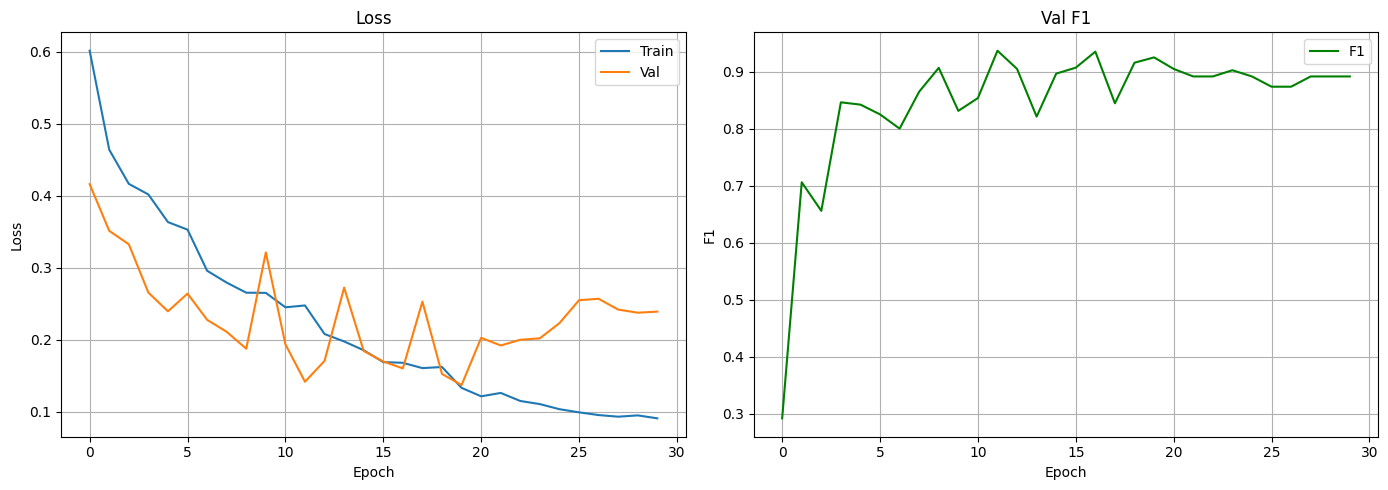

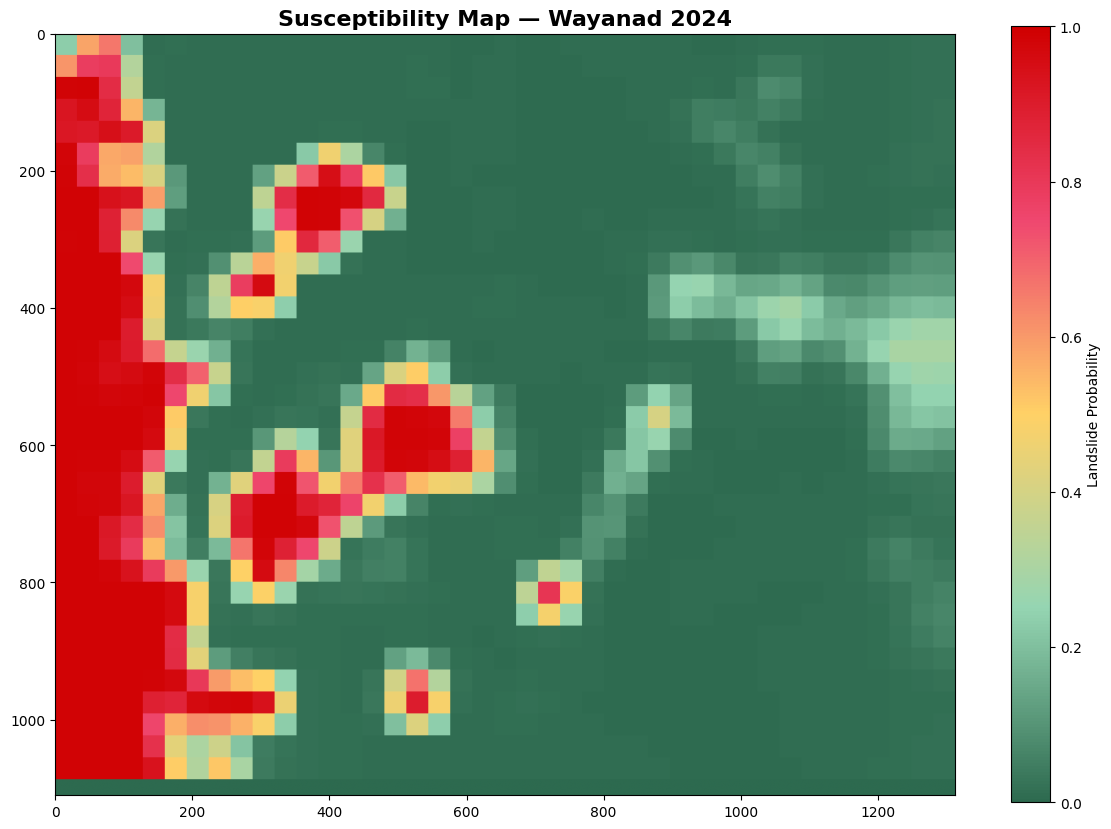

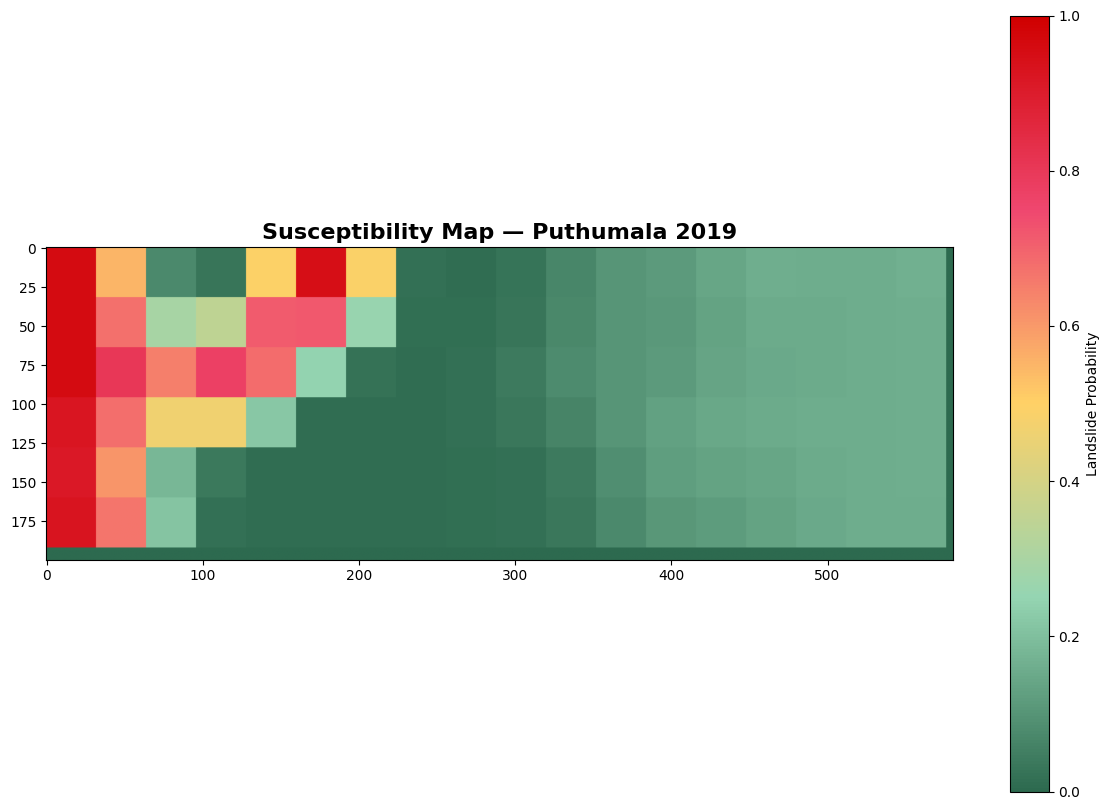


✓ Pipeline Complete!


In [ ]:
# %% [markdown]
# # LandslideMoE: Domain-Decoupled Mixture-of-Experts for Landslide Prediction
# **Architecture**: Faithful replication of EEGMoE (IEEE TNNLS) adapted for geospatial data.

# %% [markdown]
# ## 1. Setup & Installation
# %%
!pip install rasterio geopandas shapely fiona pyproj gdown netCDF4 xarray PyPDF2 -q

# %%
import os, glob, math, random, warnings, zipfile, shutil
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix)
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import rasterio
from rasterio.enums import Resampling
from rasterio.warp import reproject, calculate_default_transform
from rasterio.crs import CRS
from rasterio.transform import from_bounds
import gdown
warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# %% [markdown]
# ## 2. Download Actual Datasets
# %%
DRIVE_IDS = {
    "landslide_atlas": "1phUWEeg5m2DeJry13vpoN70WZW71iDfH",
    "wayanad_data": "1X42vJcGyTYTfOAzMgwKNRmGUKWyF4FJC",
    "wayanad_ref": "1VZFhK6X5VefdFup_rLC9PJpERi_XQBXW",
    "wayanad_impact": "1hZD3yG4Y6FeWs4fs0k9rwOGqvP_v_8gi",
    "puthumala_data": "1sQnIyzPhhsewpaCmYCyGw8GvoCKd1j60",
}
DATA_ROOT = "/content/landslide_data"
os.makedirs(DATA_ROOT, exist_ok=True)

def download_drive_file(file_id, output_path):
    """Download file from Google Drive with fallback methods."""
    if os.path.exists(output_path):
        sz = os.path.getsize(output_path)
        if sz > 10000:  # >10KB means it's likely a real file, not an HTML error page
            print(f"  Already exists: {output_path} ({sz/1024/1024:.1f}MB)")
            return
        else:
            os.remove(output_path)  # Remove tiny/corrupt files
    try:
        url = f"https://drive.google.com/uc?id={file_id}"
        gdown.download(url, output_path, quiet=False, fuzzy=True)
    except Exception as e1:
        print(f"  gdown failed: {e1}")
        print("  Trying fallback with requests session...")
        import requests
        session = requests.Session()
        r = session.get(f"https://drive.google.com/uc?export=download&id={file_id}", stream=True)
        # Check for confirmation token (large file warning)
        for key, value in r.cookies.items():
            if key.startswith('download_warning'):
                r = session.get(f"https://drive.google.com/uc?export=download&confirm={value}&id={file_id}", stream=True)
                break
        with open(output_path, 'wb') as f:
            for chunk in r.iter_content(32768):
                if chunk: f.write(chunk)
        print(f"  Fallback downloaded: {os.path.getsize(output_path)/1024/1024:.1f}MB")

def download_drive_folder(folder_id, output_dir):
    if os.path.exists(output_dir) and len(os.listdir(output_dir)) > 0:
        print(f"  Already exists: {output_dir}")
        return
    os.makedirs(output_dir, exist_ok=True)
    url = f"https://drive.google.com/drive/folders/{folder_id}"
    gdown.download_folder(url, output=output_dir, quiet=False)

# %%
print("=" * 60)
print("Downloading datasets from Google Drive...")
print("=" * 60)

atlas_dir = os.path.join(DATA_ROOT, "landslide_atlas")
os.makedirs(atlas_dir, exist_ok=True)
atlas_path = os.path.join(atlas_dir, "landslide_atlas.tif")
print("\n[1/5] Downloading LandslideAtlas (ground truth)...")
download_drive_file(DRIVE_IDS["landslide_atlas"], atlas_path)

# Verify atlas is a valid raster
atlas_valid = False
try:
    with rasterio.open(atlas_path) as src:
        print(f"  ✓ Atlas valid: {src.width}x{src.height}, CRS={src.crs}")
        atlas_valid = True
except Exception as e:
    print(f"  ✗ Atlas file not a valid raster: {e}")
    print("    This may be a shapefile/KML/GeoJSON. Checking file header...")
    with open(atlas_path, 'rb') as f:
        header = f.read(20)
    print(f"    First bytes: {header[:20]}")
    if header[:4] == b'PK\x03\x04':  # It's a zip (KMZ/shapefile bundle)
        print("    Detected as ZIP/KMZ archive. Extracting...")
        import zipfile
        with zipfile.ZipFile(atlas_path, 'r') as zf:
            zf.extractall(atlas_dir)
            print(f"    Extracted: {zf.namelist()}")

wayanad_dir = os.path.join(DATA_ROOT, "wayanad")
print("\n[2/5] Downloading Wayanad 2024 dataset...")
download_drive_folder(DRIVE_IDS["wayanad_data"], wayanad_dir)

wayanad_ref_dir = os.path.join(DATA_ROOT, "wayanad_ref")
print("\n[3/5] Downloading Wayanad reference data...")
download_drive_folder(DRIVE_IDS["wayanad_ref"], wayanad_ref_dir)

impact_dir = os.path.join(DATA_ROOT, "wayanad_impact")
os.makedirs(impact_dir, exist_ok=True)
impact_path = os.path.join(impact_dir, "impact_map.tif")
print("\n[4/5] Downloading Wayanad impact map...")
download_drive_file(DRIVE_IDS["wayanad_impact"], impact_path)

puthumala_dir = os.path.join(DATA_ROOT, "puthumala")
print("\n[5/5] Downloading Puthumala 2019 dataset...")
download_drive_folder(DRIVE_IDS["puthumala_data"], puthumala_dir)

print("\n✓ All downloads complete!")

# %% [markdown]
# ## 2b. Extract Knowledge from PDF Documents
# %%
def extract_pdf_text(pdf_path):
    """Extract text from a PDF file."""
    try:
        from PyPDF2 import PdfReader
        reader = PdfReader(pdf_path)
        text = ""
        for page in reader.pages:
            t = page.extract_text()
            if t: text += t + "\n"
        return text.strip()
    except Exception as e:
        print(f"  PDF extraction error ({os.path.basename(pdf_path)}): {e}")
        return ""

def chunk_text(text, chunk_size=200, overlap=50):
    """Split text into overlapping word-chunks for embedding."""
    words = text.split()
    chunks = []
    for i in range(0, len(words), chunk_size - overlap):
        chunk = ' '.join(words[i:i+chunk_size])
        if len(chunk.split()) > 20:  # Skip tiny fragments
            chunks.append(chunk)
    return chunks

# Find and extract ALL PDFs in data directory
print("\n" + "="*60 + "\nExtracting knowledge from PDF documents...\n" + "="*60)
pdf_knowledge_texts = []
for root, dirs, files in os.walk(DATA_ROOT):
    for f in files:
        fpath = os.path.join(root, f)
        # Check if file is actually a PDF (by content, not just extension)
        try:
            with open(fpath, 'rb') as fh:
                if fh.read(5) == b'%PDF-':
                    text = extract_pdf_text(fpath)
                    if len(text) > 100:
                        pdf_knowledge_texts.append(text)
                        print(f"  ✓ Extracted: {os.path.basename(fpath)} ({len(text):,} chars)")
        except: pass

if pdf_knowledge_texts:
    all_knowledge_text = "\n\n".join(pdf_knowledge_texts)
    knowledge_chunks = chunk_text(all_knowledge_text, chunk_size=200, overlap=50)
    print(f"\n  Total: {len(pdf_knowledge_texts)} PDFs → {len(all_knowledge_text):,} chars → {len(knowledge_chunks)} chunks")
else:
    all_knowledge_text = ""
    knowledge_chunks = []
    print("  No PDFs found.")

# %% [markdown]
# ## 3. Extract Zipped Sub-Datasets & Explore Structure
# %%
# Extract any zip files found in the data directories
for root, dirs, files in os.walk(DATA_ROOT):
    for f in files:
        if f.endswith('.zip') and 'landslide_atlas' not in root:
            zpath = os.path.join(root, f)
            extract_to = os.path.join(root, f.replace('.zip', ''))
            if not os.path.exists(extract_to):
                os.makedirs(extract_to, exist_ok=True)
                try:
                    with zipfile.ZipFile(zpath, 'r') as zf:
                        zf.extractall(extract_to)
                    print(f"Extracted: {zpath}")
                except zipfile.BadZipFile:
                    print(f"Not a valid zip: {zpath}")

# Show tree
def show_tree(path, prefix="", max_depth=3, depth=0):
    if depth >= max_depth: return
    entries = sorted(os.listdir(path)) if os.path.isdir(path) else []
    for i, e in enumerate(entries):
        fp = os.path.join(path, e)
        conn = "└── " if i == len(entries)-1 else "├── "
        sz = f" ({os.path.getsize(fp)/1024/1024:.1f}MB)" if os.path.isfile(fp) and os.path.getsize(fp) > 1024 else ""
        print(f"{prefix}{conn}{e}{sz}")
        if os.path.isdir(fp):
            show_tree(fp, prefix + ("    " if i == len(entries)-1 else "│   "), max_depth, depth+1)

print("\nData structure:")
show_tree(DATA_ROOT)

# %% [markdown]
# ## 4. CRS-Aware Data Loading Pipeline
# %%
def find_rasters(directory, extensions=('.tif', '.tiff', '.img')):
    rasters = []
    if not os.path.exists(directory): return rasters
    for root, dirs, files in os.walk(directory):
        for f in sorted(files):
            if f.lower().endswith(extensions) and not f.startswith('.'):
                rasters.append(os.path.join(root, f))
    return rasters

def get_bounds_in_4326(raster_path):
    """Get raster bounds in EPSG:4326 for universal overlap comparison."""
    with rasterio.open(raster_path) as src:
        if src.crs is None:
            return None
        if src.crs.to_epsg() == 4326:
            return src.bounds
        dst_crs = CRS.from_epsg(4326)
        transform, width, height = calculate_default_transform(
            src.crs, dst_crs, src.width, src.height, *src.bounds)
        left = transform.c
        top = transform.f
        right = left + transform.a * width
        bottom = top + transform.e * height
        from rasterio.coords import BoundingBox
        return BoundingBox(left=min(left,right), bottom=min(top,bottom),
                          right=max(left,right), top=max(top,bottom))

def bounds_overlap(b1, b2):
    if b1 is None or b2 is None: return False
    return (b1.left < b2.right and b1.right > b2.left and
            b1.bottom < b2.top and b1.top > b2.bottom)

def load_and_resample(src_path, dst_crs, dst_transform, dst_width, dst_height):
    """Load raster and reproject to destination grid."""
    with rasterio.open(src_path) as src:
        data = np.empty((src.count, dst_height, dst_width), dtype=np.float32)
        for b in range(src.count):
            reproject(
                source=rasterio.band(src, b+1),
                destination=data[b],
                src_transform=src.transform, src_crs=src.crs,
                dst_transform=dst_transform, dst_crs=dst_crs,
                resampling=Resampling.bilinear)
    return data

def load_netcdf_as_band(nc_path, target_bounds_4326, dst_crs, dst_transform, dst_w, dst_h):
    """Load NetCDF rainfall data and resample to target grid."""
    try:
        import xarray as xr
        ds = xr.open_dataset(nc_path)
        # Find the rainfall variable
        rain_var = None
        for v in ds.data_vars:
            if any(k in v.lower() for k in ['rain', 'precip', 'rf', 'tp']):
                rain_var = v; break
        if rain_var is None:
            rain_var = list(ds.data_vars)[0]
        data = ds[rain_var].values
        if data.ndim == 3:  # (time, lat, lon) -> sum over time
            data = np.nansum(data, axis=0).astype(np.float32)
        elif data.ndim > 3:
            data = np.nansum(data, axis=tuple(range(data.ndim-2))).astype(np.float32)
        # Get coords
        lat = ds.coords.get('lat', ds.coords.get('latitude', ds.coords.get('LAT')))
        lon = ds.coords.get('lon', ds.coords.get('longitude', ds.coords.get('LON')))
        if lat is None or lon is None:
            for c in ds.coords:
                if 'lat' in c.lower(): lat = ds.coords[c]
                if 'lon' in c.lower(): lon = ds.coords[c]
        lat_vals, lon_vals = lat.values, lon.values
        # Create in-memory raster and reproject
        src_transform = from_bounds(
            lon_vals.min(), lat_vals.min(), lon_vals.max(), lat_vals.max(),
            data.shape[1], data.shape[0])
        out = np.empty((1, dst_h, dst_w), dtype=np.float32)
        reproject(
            source=data, destination=out[0],
            src_transform=src_transform, src_crs=CRS.from_epsg(4326),
            dst_transform=dst_transform, dst_crs=dst_crs,
            resampling=Resampling.bilinear)
        ds.close()
        return out
    except Exception as e:
        print(f"    NetCDF load error: {e}")
        return None

def classify_raster(filepath):
    name = os.path.basename(filepath).lower()
    parent = os.path.basename(os.path.dirname(filepath)).lower()
    combined = f"{parent}/{name}"
    if any(k in combined for k in ['sentinel-1','sentinel1','s1','sar','vv','vh','backscatter','sigma','coherence']):
        return 'SAR'
    elif any(k in combined for k in ['sentinel-2','sentinel2','s2','b01','b02','b03','b04','b05','b06','b07','b08','b09','b11','b12','b8a','ndvi','optical','multispectral']):
        return 'Optical'
    elif any(k in combined for k in ['rain','precip','imd','chirps']):
        return 'Hydromet'
    elif any(k in combined for k in ['soil','moisture','smap','sm_']):
        return 'Soil'
    elif any(k in combined for k in ['dem','elevation','slope','aspect','srtm','copernicus_dem']):
        return 'DEM'
    elif any(k in combined for k in ['atlas','label','ground_truth','gt','mask','landslide','impact','inventory']):
        return 'Label'
    return 'Other'

def normalize_bands(data):
    for c in range(data.shape[0]):
        band = data[c]
        valid = band[~np.isnan(band)]
        if len(valid) > 0:
            p2, p98 = np.percentile(valid, [2, 98])
            if p98 - p2 > 1e-8:
                data[c] = np.clip((band - p2) / (p98 - p2), 0, 1)
            else:
                data[c] = 0.0
        else:
            data[c] = 0.0
    return np.nan_to_num(data, 0.0)

# %%
def aggregate_domain_bands(all_bands, channel_info, domain_ids, domain_name, max_bands=3):
    """Aggregate bands from a domain into summary statistics (mean, max, std) if too many."""
    indices = [i for i, info in enumerate(channel_info) if info.startswith(domain_name + ':')]
    if len(indices) <= max_bands:
        return all_bands, channel_info, domain_ids  # No aggregation needed

    domain_data = np.stack([all_bands[i] for i in indices], axis=0)  # (N, H, W)
    agg_mean = np.nanmean(domain_data, axis=0)
    agg_max = np.nanmax(domain_data, axis=0)
    agg_std = np.nanstd(domain_data, axis=0)

    # Remove original bands and insert aggregated ones
    keep_mask = [i for i in range(len(all_bands)) if i not in indices]
    new_bands = [all_bands[i] for i in keep_mask]
    new_info = [channel_info[i] for i in keep_mask]
    new_dom = [domain_ids[i] for i in keep_mask]

    dom_id = domain_ids[indices[0]]
    for arr, suffix in [(agg_mean, 'mean'), (agg_max, 'max'), (agg_std, 'std')]:
        new_bands.append(arr)
        new_info.append(f"{domain_name}:aggregated:{suffix}")
        new_dom.append(dom_id)

    print(f"  Aggregated {len(indices)} {domain_name} bands → 3 summary bands (mean/max/std)")
    return new_bands, new_info, new_dom

def generate_slope_from_dem(stacked, channel_info, ref_transform):
    """Generate slope from DEM band for pseudo-label creation."""
    dem_idx = None
    for i, info in enumerate(channel_info):
        if 'DEM' in info or 'dem' in info.lower():
            dem_idx = i; break
    if dem_idx is None:
        return None

    dem = stacked[dem_idx]
    # Compute slope using numpy gradient
    px_size = abs(ref_transform.a)  # pixel size in CRS units (meters for UTM)
    if px_size < 0.01: px_size = 30.0  # fallback if in degrees
    dy, dx = np.gradient(dem, px_size)
    slope = np.degrees(np.arctan(np.sqrt(dx**2 + dy**2)))
    return slope

def generate_pseudo_labels(stacked, channel_info, ref_transform, site_name):
    """Generate landslide susceptibility pseudo-labels using geomorphological indicators."""
    H, W = stacked.shape[1], stacked.shape[2]

    # 1. Slope from DEM (steep slopes > 15° are landslide-prone)
    slope = generate_slope_from_dem(stacked, channel_info, ref_transform)
    slope_risk = np.zeros((H, W), dtype=np.float32)
    if slope is not None:
        slope_risk = np.clip((slope - 15.0) / 30.0, 0, 1)  # Normalize: 15°-45° → 0-1
        print(f"  DEM slope: mean={np.nanmean(slope):.1f}°, max={np.nanmax(slope):.1f}°")

    # 2. High soil moisture (saturated soil increases risk)
    sm_risk = np.zeros((H, W), dtype=np.float32)
    for i, info in enumerate(channel_info):
        if 'Soil' in info and 'mean' in info:
            sm = stacked[i]
            sm_risk = np.clip((sm - np.nanpercentile(sm[sm > 0], 70)) /
                             (np.nanpercentile(sm[sm > 0], 95) - np.nanpercentile(sm[sm > 0], 70) + 1e-8), 0, 1)
            print(f"  Soil moisture risk computed")
            break

    # 3. Vegetation loss (low NDVI from optical bands indicates exposed soil)
    ndvi_risk = np.zeros((H, W), dtype=np.float32)
    nir_idx, red_idx = None, None
    for i, info in enumerate(channel_info):
        if 'B08' in info and nir_idx is None: nir_idx = i  # Sentinel-2 Band 8 (NIR)
        if 'B04' in info and red_idx is None: red_idx = i   # Sentinel-2 Band 4 (Red)
    if nir_idx is not None and red_idx is not None:
        nir, red = stacked[nir_idx].astype(np.float64), stacked[red_idx].astype(np.float64)
        ndvi = (nir - red) / (nir + red + 1e-8)
        ndvi_risk = np.clip(0.3 - ndvi, 0, 0.6) / 0.6  # Low NDVI (<0.3) = high risk
        print(f"  NDVI risk: bare soil pixels = {np.mean(ndvi < 0.2)*100:.1f}%")

    # 4. High rainfall increases risk
    rain_risk = np.zeros((H, W), dtype=np.float32)
    for i, info in enumerate(channel_info):
        if 'Hydromet' in info:
            r = stacked[i]
            valid = r[r > 0]
            if len(valid) > 0:
                rain_risk = np.clip((r - np.percentile(valid, 60)) /
                                   (np.percentile(valid, 95) - np.percentile(valid, 60) + 1e-8), 0, 1)
            print(f"  Rainfall risk computed")
            break

    # Combine multi-factor susceptibility
    combined = 0.35 * slope_risk + 0.25 * sm_risk + 0.25 * ndvi_risk + 0.15 * rain_risk
    threshold = np.percentile(combined[combined > 0], 85)  # Top 15% as landslide-prone
    labels = (combined > threshold).astype(np.float32)

    pct = np.mean(labels > 0) * 100
    print(f"  Pseudo-labels: {pct:.1f}% landslide pixels (threshold={threshold:.3f})")
    return labels

def load_site_data(site_dir, label_paths, site_name="Site"):
    """Load all rasters for a site using CRS-aware alignment."""
    print(f"\n{'='*60}\nLoading: {site_name}\n{'='*60}")

    all_rasters = find_rasters(site_dir)
    nc_files = []
    for root, dirs, files in os.walk(site_dir):
        for f in files:
            if f.lower().endswith('.nc'):
                nc_files.append(os.path.join(root, f))

    classified = {}
    for r in all_rasters:
        cls = classify_raster(r)
        if cls != 'Label':
            classified.setdefault(cls, []).append(r)

    print(f"Found rasters:")
    for domain, files in classified.items():
        print(f"  {domain}: {len(files)} files")
    if nc_files:
        print(f"  NetCDF (Rainfall): {len(nc_files)} files")

    # Pick reference: prefer SAR > Optical > DEM
    ref_path = None
    for priority_domain in ['SAR', 'Optical', 'DEM', 'Soil', 'Other']:
        for r in classified.get(priority_domain, []):
            try:
                with rasterio.open(r) as src:
                    if src.crs is not None:
                        ref_path = r; break
            except: continue
        if ref_path: break

    if ref_path is None:
        print("ERROR: No valid georeferenced rasters found!")
        return None, None, [], [], None

    with rasterio.open(ref_path) as src:
        ref_crs = src.crs
        ref_transform = src.transform
        ref_w, ref_h = src.width, src.height
    ref_bounds_4326 = get_bounds_in_4326(ref_path)
    print(f"Reference: {os.path.basename(ref_path)} ({ref_w}x{ref_h}, CRS={ref_crs})")

    # Stack all bands with CRS-aware overlap
    all_bands, channel_info, domain_ids = [], [], []
    domain_map = {'SAR': 0, 'Optical': 1, 'Hydromet': 2, 'Soil': 3, 'DEM': 3, 'Other': 1}

    for domain in ['SAR', 'Optical', 'DEM', 'Soil', 'Other']:
        for rpath in classified.get(domain, []):
            try:
                r_bounds_4326 = get_bounds_in_4326(rpath)
                if not bounds_overlap(ref_bounds_4326, r_bounds_4326):
                    continue
                data = load_and_resample(rpath, ref_crs, ref_transform, ref_w, ref_h)
                for b in range(data.shape[0]):
                    all_bands.append(data[b])
                    channel_info.append(f"{domain}:{os.path.basename(rpath)}:B{b+1}")
                    domain_ids.append(domain_map.get(domain, 1))
                print(f"  ✓ {os.path.basename(rpath)} ({data.shape[0]} bands) [{domain}]")
            except Exception as e:
                print(f"  ✗ Error {os.path.basename(rpath)}: {e}")

    # Load NetCDF rainfall
    for nc_path in nc_files:
        nc_data = load_netcdf_as_band(nc_path, ref_bounds_4326, ref_crs, ref_transform, ref_w, ref_h)
        if nc_data is not None:
            all_bands.append(nc_data[0])
            channel_info.append(f"Hydromet:{os.path.basename(nc_path)}:rain")
            domain_ids.append(2)
            print(f"  ✓ {os.path.basename(nc_path)} (rainfall) [Hydromet]")

    if len(all_bands) == 0:
        print("ERROR: No bands loaded!")
        return None, None, [], [], None

    # Aggregate Soil Moisture (201 bands → 3: mean/max/std)
    all_bands, channel_info, domain_ids = aggregate_domain_bands(
        all_bands, channel_info, domain_ids, 'Soil', max_bands=5)

    stacked = normalize_bands(np.stack(all_bands, axis=0))
    print(f"\nFinal stacked: {stacked.shape} ({len(channel_info)} channels)")
    for i, info in enumerate(channel_info):
        print(f"  Ch{i:2d}: {info} [domain={domain_ids[i]}]")

    # Try loading raster labels
    labels = np.zeros((ref_h, ref_w), dtype=np.float32)
    label_loaded = False
    for lpath in label_paths:
        if not os.path.exists(lpath): continue
        # Skip files that are PDFs
        try:
            with open(lpath, 'rb') as f:
                if f.read(5) == b'%PDF-':
                    continue
        except: pass
        try:
            l_bounds_4326 = get_bounds_in_4326(lpath)
            if not bounds_overlap(ref_bounds_4326, l_bounds_4326):
                continue
            ldata = load_and_resample(lpath, ref_crs, ref_transform, ref_w, ref_h)
            labels = np.maximum(labels, (ldata[0] > 0).astype(np.float32))
            label_loaded = True
            print(f"  ✓ Label loaded: {os.path.basename(lpath)}")
        except Exception as e:
            pass  # Skip silently — we know atlas/impact are PDFs

    if not label_loaded:
        print("  No raster labels available. Generating physics-based pseudo-labels...")
        labels = generate_pseudo_labels(stacked, channel_info, ref_transform, site_name)

    print(f"Label stats: {np.mean(labels>0)*100:.2f}% landslide pixels")
    return stacked, labels, channel_info, domain_ids, ref_transform

# %% [markdown]
# ## 5. Config & Knowledge Encoder
# %%
class Config:
    PATCH_SIZE = 16; IMG_SIZE = 64
    IN_CHANNELS = None; NUM_PATCHES = (IMG_SIZE // PATCH_SIZE) ** 2
    NUM_DOMAINS = 5; DOMAIN_MAP = None  # domain 4 = Knowledge/Text
    D_MODEL = 256; N_HEADS = 8; N_LAYERS = 6; D_FF = 512; DROPOUT = 0.1
    N_SHARED_EXPERTS = 2; N_SPECIFIC_EXPERTS = 6; TOP_K = 2
    LOAD_BALANCE_ALPHA = 0.01; MASK_RATIO = 0.4
    PRETRAIN_EPOCHS = 50; PRETRAIN_LR = 1e-4
    FINETUNE_EPOCHS = 30; FINETUNE_LR = 5e-5
    BATCH_SIZE = 32; NUM_CLASSES = 1
    N_KNOWLEDGE_TOKENS = 8  # Number of knowledge tokens injected into encoder
    VOCAB_SIZE = 10000       # Simple word-level vocabulary size
cfg = Config()

# %%
class TextKnowledgeEncoder(nn.Module):
    """
    Encodes text chunks from PDFs into d_model-dimensional knowledge tokens.
    These tokens are prepended to spatial tokens and routed through domain-4
    experts in the MoE, allowing experts to specialize in paper knowledge.

    Uses a simple learned word embedding + positional encoding + mean pooling.
    """
    def __init__(self, vocab_size, d_model, n_tokens, max_words=200):
        super().__init__()
        self.n_tokens = n_tokens
        self.max_words = max_words
        self.word_embed = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos_embed = nn.Parameter(torch.randn(1, max_words, d_model) * 0.02)
        self.proj = nn.Sequential(
            nn.Linear(d_model, d_model), nn.GELU(),
            nn.Linear(d_model, d_model * n_tokens)
        )
        self.norm = nn.LayerNorm(d_model)

    def forward(self, token_ids):
        # token_ids: (B, max_words) word indices
        B = token_ids.shape[0]
        x = self.word_embed(token_ids)  # (B, max_words, d_model)
        x = x + self.pos_embed[:, :x.shape[1], :]
        # Mean pool over words
        mask = (token_ids > 0).float().unsqueeze(-1)  # (B, max_words, 1)
        x = (x * mask).sum(dim=1) / (mask.sum(dim=1) + 1e-8)  # (B, d_model)
        # Project to n_tokens knowledge tokens
        x = self.proj(x)  # (B, d_model * n_tokens)
        x = x.view(B, self.n_tokens, -1)  # (B, n_tokens, d_model)
        return self.norm(x)

# Build vocabulary from extracted knowledge
def build_vocab(texts, max_vocab=10000):
    word_freq = {}
    for text in texts:
        for w in text.lower().split():
            w = ''.join(c for c in w if c.isalnum())
            if w: word_freq[w] = word_freq.get(w, 0) + 1
    sorted_words = sorted(word_freq.items(), key=lambda x: -x[1])[:max_vocab-2]
    vocab = {'<PAD>': 0, '<UNK>': 1}
    for w, _ in sorted_words:
        vocab[w] = len(vocab)
    return vocab

def tokenize_chunk(chunk, vocab, max_len=200):
    words = chunk.lower().split()
    ids = [vocab.get(''.join(c for c in w if c.isalnum()), 1) for w in words[:max_len]]
    ids += [0] * (max_len - len(ids))  # pad
    return ids

# Build vocab and tokenize chunks
if knowledge_chunks:
    knowledge_vocab = build_vocab(knowledge_chunks, cfg.VOCAB_SIZE)
    knowledge_token_ids = np.array([tokenize_chunk(c, knowledge_vocab) for c in knowledge_chunks], dtype=np.int64)
    print(f"Knowledge vocab: {len(knowledge_vocab)} words, {knowledge_token_ids.shape[0]} chunks")
else:
    knowledge_vocab = {'<PAD>': 0, '<UNK>': 1}
    knowledge_token_ids = np.zeros((1, 200), dtype=np.int64)  # dummy
    print("No knowledge chunks; using empty knowledge.")

# %% [markdown]
# ## 6. Create Tiles & Datasets
# %%
def create_tiles(data, labels, tile_size=64, stride=32, min_valid=0.5):
    C, H, W = data.shape
    tiles_x, tiles_y = [], []
    for i in range(0, H - tile_size + 1, stride):
        for j in range(0, W - tile_size + 1, stride):
            tile = data[:, i:i+tile_size, j:j+tile_size]
            if np.mean(np.any(tile != 0, axis=0)) < min_valid: continue
            ls_ratio = np.mean(labels[i:i+tile_size, j:j+tile_size] > 0)
            tiles_x.append(tile)
            tiles_y.append(1.0 if ls_ratio > 0.05 else 0.0)
    return np.array(tiles_x, np.float32), np.array(tiles_y, np.float32)

class LandslideDataset(Dataset):
    def __init__(self, X, y, domain_ids_list, knowledge_ids=None):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
        self.domain_ids = torch.LongTensor(domain_ids_list)
        # Sample random knowledge chunks per batch item for diversity
        if knowledge_ids is not None and len(knowledge_ids) > 0:
            self.knowledge_ids = torch.LongTensor(knowledge_ids)
        else:
            self.knowledge_ids = torch.zeros(1, 200, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, idx):
        # Sample a random knowledge chunk for this item
        k_idx = idx % len(self.knowledge_ids)
        return self.X[idx], self.y[idx], self.domain_ids, self.knowledge_ids[k_idx]

# %% [markdown]
# ## 7. Load All Sites
# %%
# Collect label candidates (even if they're PDFs, we check format inside load_site_data)
label_files = []
for root, dirs, files in os.walk(DATA_ROOT):
    for f in files:
        fp = os.path.join(root, f)
        if classify_raster(fp) == 'Label':
            label_files.append(fp)
print(f"Label candidates: {[os.path.basename(f) for f in label_files]}")

wayanad_data, wayanad_labels, wayanad_ch, wayanad_dom, wayanad_tf = load_site_data(
    wayanad_dir, label_files, "Wayanad 2024")
puthumala_data, puthumala_labels, puthumala_ch, puthumala_dom, puthumala_tf = load_site_data(
    puthumala_dir, label_files, "Puthumala 2019")

# %%
# Smart Channel Alignment: map matching band types instead of zero-padding
def align_channels(data_a, ch_a, dom_a, data_b, ch_b, dom_b):
    """
    Align channels between two sites by matching band types.
    Returns both datasets with identical channel ordering.
    Maps: SAR→SAR, Optical→Optical, DEM→DEM, Soil→Soil, Hydromet→Hydromet.
    Missing channels are filled with site-local mean (not zeros).
    """
    # Build canonical channel order from site A (larger)
    canonical = []  # list of (channel_info, domain_id)
    for i, (ci, di) in enumerate(zip(ch_a, dom_a)):
        band_type = ci.split(':')[0]  # SAR, Optical, DEM, Soil, Hydromet
        canonical.append((ci, di, band_type))

    # For each canonical channel, find best match in site B
    used_b = set()
    b_mapping = {}  # canonical_idx -> b_idx

    for c_idx, (ci, di, bt) in enumerate(canonical):
        best_match = None
        for b_idx in range(len(ch_b)):
            if b_idx in used_b:
                continue
            b_type = ch_b[b_idx].split(':')[0]
            if b_type == bt:
                best_match = b_idx
                break
        if best_match is not None:
            b_mapping[c_idx] = best_match
            used_b.add(best_match)

    n_ch = len(canonical)
    H_b, W_b = data_b.shape[1], data_b.shape[2]
    aligned_b = np.zeros((n_ch, H_b, W_b), dtype=np.float32)
    aligned_dom_b = []

    for c_idx in range(n_ch):
        if c_idx in b_mapping:
            aligned_b[c_idx] = data_b[b_mapping[c_idx]]
        else:
            # Fill with channel-wise mean from site B (not zeros)
            band_type = canonical[c_idx][2]
            same_type = [j for j in range(len(ch_b)) if ch_b[j].split(':')[0] == band_type]
            if same_type:
                aligned_b[c_idx] = np.mean(data_b[same_type], axis=0)
            # else: stays zero (no matching type at all)
        aligned_dom_b.append(canonical[c_idx][1])

    matched = len(b_mapping)
    print(f"  Channel alignment: {matched}/{n_ch} channels matched, {n_ch-matched} filled with type-mean")
    return data_a, dom_a, aligned_b, aligned_dom_b

print("\n" + "="*60 + "\nChannel Alignment\n" + "="*60)
wayanad_aligned, wayanad_dom_a, puthumala_aligned, puthumala_dom_a = align_channels(
    wayanad_data, wayanad_ch, wayanad_dom,
    puthumala_data, puthumala_ch, puthumala_dom
)

# Shared pseudo-label threshold: use combined statistics
w_labels = wayanad_labels
p_labels = puthumala_labels
w_pos = np.mean(w_labels > 0) * 100
p_pos = np.mean(p_labels > 0) * 100
print(f"  Wayanad labels: {w_pos:.1f}% positive | Puthumala labels: {p_pos:.1f}% positive")

# Use stride=32 (50% overlap) to stay within Colab RAM limits
TILE_STRIDE = 32

wx, wy = create_tiles(wayanad_aligned, w_labels, cfg.IMG_SIZE, TILE_STRIDE)
print(f"\nWayanad: {wx.shape[0]} tiles ({np.mean(wy)*100:.1f}% positive)")

px, py = create_tiles(puthumala_aligned, p_labels, cfg.IMG_SIZE, TILE_STRIDE)
print(f"Puthumala: {px.shape[0]} tiles ({np.mean(py)*100:.1f}% positive)")

# Data Augmentation for Puthumala (4x: original + 3 rotations)
print(f"  Augmenting Puthumala tiles...")
aug_x, aug_y = [px], [py]
for k in range(1, 4):  # 90°, 180°, 270° rotations
    aug_x.append(np.rot90(px, k=k, axes=(2, 3)).copy())
    aug_y.append(py.copy())
# Horizontal flip
aug_x.append(px[:, :, :, ::-1].copy())
aug_y.append(py.copy())
px_aug = np.concatenate(aug_x)
py_aug = np.concatenate(aug_y)
print(f"  Puthumala augmented: {px.shape[0]} → {px_aug.shape[0]} tiles")

# Free raw raster arrays (keep aligned for susceptibility maps)
del wayanad_data, wayanad_labels, puthumala_data, puthumala_labels
import gc; gc.collect()

# %%
cfg.IN_CHANNELS = len(wayanad_dom_a)
cfg.DOMAIN_MAP = {i: wayanad_dom_a[i] for i in range(cfg.IN_CHANNELS)}
dom_tensor = [cfg.DOMAIN_MAP.get(c, 0) for c in range(cfg.IN_CHANNELS)]

# Mixed Training: Wayanad 85/15 train/val + Puthumala 70/30 train/test
n_w = len(wx); idx_w = np.random.permutation(n_w); w_tr = int(0.85 * n_w)
n_p = len(px_aug); idx_p = np.random.permutation(n_p); p_tr = int(0.70 * n_p)

# Combine Wayanad-train + Puthumala-train for mixed training
train_X = np.concatenate([wx[idx_w[:w_tr]], px_aug[idx_p[:p_tr]]])
train_y = np.concatenate([wy[idx_w[:w_tr]], py_aug[idx_p[:p_tr]]])
train_idx = np.random.permutation(len(train_X))
train_ds = LandslideDataset(train_X[train_idx], train_y[train_idx], dom_tensor, knowledge_token_ids)
del train_X, train_y; gc.collect()

# Separate validation sets for per-site evaluation
val_ds = LandslideDataset(wx[idx_w[w_tr:]], wy[idx_w[w_tr:]], dom_tensor, knowledge_token_ids)
del wx, wy; gc.collect()

# Puthumala held-out test (30% of augmented, but use ORIGINAL un-augmented for fair eval)
puthumala_test_ds = LandslideDataset(px, py, dom_tensor, knowledge_token_ids)
del px, py, px_aug, py_aug; gc.collect()

train_loader = DataLoader(train_ds, batch_size=cfg.BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=cfg.BATCH_SIZE, shuffle=False)
puthumala_loader = DataLoader(puthumala_test_ds, batch_size=cfg.BATCH_SIZE, shuffle=False)

print(f"\n{'='*60}\nDATA SPLIT (Mixed Training)\n{'='*60}")
print(f"Channels: {cfg.IN_CHANNELS} | Tile size: {cfg.IMG_SIZE} | Stride: {TILE_STRIDE}")
print(f"Mixed Train (W+P):      {len(train_ds)} tiles")
print(f"Wayanad Val:            {len(val_ds)} tiles")
print(f"Puthumala Test:         {len(puthumala_test_ds)} tiles (original, un-augmented)")

# %% [markdown]
# ## 8. EEGMoE Architecture
# ### 8.1 Patch Embedding
# %%
class DualEncoderTokenization(nn.Module):
    """
    EEGMoE Tokenization: Projects 4D input to 2D tokens via Spatial & Spectral encoders.
    Original EEG 4D: (Batch, Channels, Spatial, Frequency)
    Geospatial 4D: (Batch, Channels, Height, Width)

    The Spatial Encoder processes height/width (spatial domain).
    The Spectral Encoder processes channels (representing spectral/frequency bands).
    """
    def __init__(self, in_channels, d_model, patch_size, img_size, num_domains):
        super().__init__()
        self.num_patches = (img_size // patch_size) ** 2

        # Spatial Encoder: 2D Conv over Height/Width
        self.spatial_encoder = nn.Conv2d(in_channels, d_model // 2, kernel_size=patch_size, stride=patch_size)

        # Spectral Encoder: 1D Conv over Channels (treated as frequency/spectral bands)
        # We reshape to (B*NumPatches, 1, In_Channels) to run a 1D conv over the channel dimension
        # and then project it to (d_model // 2)
        self.spectral_encoder = nn.Sequential(
            nn.Linear(in_channels, d_model // 2),
            nn.GELU(),
            nn.Linear(d_model // 2, d_model // 2)
        )

        # Positional and domain embeddings add to the combined 2D tokens
        self.pos_embed = nn.Parameter(torch.randn(1, self.num_patches, d_model) * 0.02)
        self.domain_embed = nn.Embedding(num_domains, d_model)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x, domain_ids):
        # x: (B, C, H, W) -> 4D tensor
        B, C, H, W = x.shape

        # 1. Spatial Encoding (extracts 2D spatial features)
        spatial_tokens = self.spatial_encoder(x)             # (B, d_model//2, H/P, W/P)
        spatial_tokens = spatial_tokens.flatten(2).transpose(1, 2)  # (B, N, d_model//2)

        # 2. Spectral Encoding (extracts 1D channel/band features for each patch)
        # Average pooling over each patch to get a single spectral vector per patch
        N_H, N_W = H // self.spatial_encoder.kernel_size[0], W // self.spatial_encoder.kernel_size[1]
        x_patches = x.view(B, C, N_H, self.spatial_encoder.kernel_size[0], N_W, self.spatial_encoder.kernel_size[1])
        x_patches = x_patches.permute(0, 2, 4, 1, 3, 5).contiguous().view(B, N_H * N_W, C, -1)
        spectral_avg = x_patches.mean(dim=-1)                # (B, N, C)
        spectral_tokens = self.spectral_encoder(spectral_avg) # (B, N, d_model//2)

        # 3. Concatenate to form final 2D tokens (B, N, d_model)
        tokens = torch.cat([spatial_tokens, spectral_tokens], dim=-1)

        # 4. Add Embeddings
        tokens = tokens + self.pos_embed
        d_emb = self.domain_embed(domain_ids).mean(dim=1, keepdim=True)
        tokens = tokens + d_emb.expand_as(tokens)

        return self.norm(tokens)

# Alias to map seamlessly into our existing codebase without renaming everything
PatchEmbedding = DualEncoderTokenization

# %% [markdown]
# ### 8.2 Domain-Decoupled MoE Block
# %%
class Expert(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(d_model, d_ff), nn.GELU(), nn.Dropout(dropout),
                                 nn.Linear(d_ff, d_model), nn.Dropout(dropout))
    def forward(self, x): return self.net(x)

class SharedExpertGroup(nn.Module):
    """Soft routing: ALL experts contribute, weighted by gate."""
    def __init__(self, n_experts, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.experts = nn.ModuleList([Expert(d_model, d_ff, dropout) for _ in range(n_experts)])
        self.gate = nn.Linear(d_model, n_experts)
    def forward(self, x):
        gate_scores = F.softmax(self.gate(x), dim=-1)
        output = torch.zeros_like(x)
        for i, exp in enumerate(self.experts):
            output = output + gate_scores[:,:,i].unsqueeze(-1) * exp(x)
        return output, gate_scores

class SpecificExpertGroup(nn.Module):
    """Top-K routing: only K experts activated per token."""
    def __init__(self, n_experts, d_model, d_ff, top_k=2, dropout=0.1):
        super().__init__()
        self.n_experts = n_experts; self.top_k = top_k
        self.experts = nn.ModuleList([Expert(d_model, d_ff, dropout) for _ in range(n_experts)])
        self.gate = nn.Linear(d_model, n_experts)
    def forward(self, x):
        B, N, D = x.shape
        gate_logits = self.gate(x)
        topk_logits, topk_idx = gate_logits.topk(self.top_k, dim=-1)
        topk_scores = F.softmax(topk_logits, dim=-1)
        output = torch.zeros(B, N, D, device=x.device, dtype=x.dtype)
        for k in range(self.top_k):
            eidx = topk_idx[:,:,k]
            w = topk_scores[:,:,k].unsqueeze(-1)
            for i in range(self.n_experts):
                mask = (eidx == i)
                if mask.any():
                    inp = x[mask]
                    eout = self.experts[i](inp)
                    buf = torch.zeros(B, N, D, device=x.device, dtype=eout.dtype)
                    buf[mask] = eout
                    output = output + w * buf
        gate_scores = F.softmax(gate_logits, dim=-1)
        return output, gate_scores, topk_idx

class DomainDecoupledMoEBlock(nn.Module):
    """Output = Shared + Specific + LoadBalanceLoss."""
    def __init__(self, d_model, d_ff, n_shared, n_specific, top_k, dropout=0.1):
        super().__init__()
        self.shared = SharedExpertGroup(n_shared, d_model, d_ff, dropout)
        self.specific = SpecificExpertGroup(n_specific, d_model, d_ff, top_k, dropout)
    def forward(self, x):
        s_out, _ = self.shared(x)
        sp_out, sp_gates, topk_idx = self.specific(x)
        lb = self._lb_loss(sp_gates, topk_idx)
        return s_out + sp_out, lb
    def _lb_loss(self, gates, topk_idx):
        n = self.specific.n_experts
        B, N, K = topk_idx.shape
        flat = topk_idx.reshape(-1)
        counts = torch.zeros(n, device=gates.device)
        for i in range(n): counts[i] = (flat == i).float().sum()
        f = counts / (B*N*K + 1e-8)
        P = gates.mean(dim=[0,1])
        return n * (f * P).sum()

# %% [markdown]
# ### 8.3 Encoder
# %%
class EEGMoEEncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, n_shared, n_specific, top_k, dropout=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model); self.norm2 = nn.LayerNorm(d_model)
        self.moe = DomainDecoupledMoEBlock(d_model, d_ff, n_shared, n_specific, top_k, dropout)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x):
        res = x; x = self.norm1(x); att, _ = self.attn(x, x, x); x = res + self.dropout(att)
        res = x; moe_out, lb = self.moe(self.norm2(x)); x = res + self.dropout(moe_out)
        return x, lb

class EEGMoEEncoder(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, n_layers, n_shared, n_specific, top_k, dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList([EEGMoEEncoderLayer(
            d_model, n_heads, d_ff, n_shared, n_specific, top_k, dropout) for _ in range(n_layers)])
        self.norm = nn.LayerNorm(d_model)
    def forward(self, x):
        total_lb = 0.0
        for layer in self.layers: x, lb = layer(x); total_lb += lb
        return self.norm(x), total_lb

# %% [markdown]
# ### 8.4 MAE Pretraining & Classification
# %%
class LandslideMoE_MAE(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.patch_embed = PatchEmbedding(cfg.IN_CHANNELS, cfg.D_MODEL, cfg.PATCH_SIZE, cfg.IMG_SIZE, cfg.NUM_DOMAINS)
        self.knowledge_embed = TextKnowledgeEncoder(cfg.VOCAB_SIZE, cfg.D_MODEL, cfg.N_KNOWLEDGE_TOKENS)
        self.encoder = EEGMoEEncoder(cfg.D_MODEL, cfg.N_HEADS, cfg.D_FF, cfg.N_LAYERS,
                                     cfg.N_SHARED_EXPERTS, cfg.N_SPECIFIC_EXPERTS, cfg.TOP_K, cfg.DROPOUT)
        self.mask_token = nn.Parameter(torch.randn(1, 1, cfg.D_MODEL) * 0.02)
        self.decoder = nn.Sequential(nn.Linear(cfg.D_MODEL, cfg.D_FF), nn.GELU(),
                                     nn.Linear(cfg.D_FF, cfg.IN_CHANNELS * cfg.PATCH_SIZE**2))
    def forward(self, x, domain_ids, knowledge_ids):
        B = x.shape[0]; tokens = self.patch_embed(x, domain_ids); N_spatial = tokens.shape[1]

        # Add Knowledge Tokens
        k_tokens = self.knowledge_embed(knowledge_ids)  # (B, N_K, D)
        k_domain = torch.full((B, k_tokens.shape[1]), 4, dtype=torch.long, device=x.device)  # Domain 4
        k_tokens = k_tokens + self.patch_embed.domain_embed(k_domain)

        # Combine (Knowledge + Spatial)
        tokens = torch.cat([k_tokens, tokens], dim=1)
        N = tokens.shape[1]

        target = x.unfold(2, self.cfg.PATCH_SIZE, self.cfg.PATCH_SIZE).unfold(3, self.cfg.PATCH_SIZE, self.cfg.PATCH_SIZE)
        target = target.contiguous().view(B, self.cfg.IN_CHANNELS, -1, self.cfg.PATCH_SIZE, self.cfg.PATCH_SIZE)
        target = target.permute(0,2,1,3,4).contiguous().view(B, N_spatial, -1)

        # Masking (only mask spatial tokens, keep knowledge visible)
        n_mask = int(N_spatial * self.cfg.MASK_RATIO)
        ids = torch.argsort(torch.rand(B, N_spatial, device=x.device), dim=1)
        mask_ids, vis_ids = ids[:, :n_mask], ids[:, n_mask:]

        # Visible tokens = Knowledge + Visible Spatial
        vis_spatial_tok = torch.gather(tokens[:, k_tokens.shape[1]:], 1, vis_ids.unsqueeze(-1).expand(-1, -1, self.cfg.D_MODEL))
        vis_tok = torch.cat([k_tokens, vis_spatial_tok], dim=1)

        enc, lb = self.encoder(vis_tok)

        # Restore full sequence for decoding
        full_spatial = self.mask_token.expand(B, N_spatial, -1).clone()
        # Spatial encodings start after knowledge tokens
        enc_spatial = enc[:, k_tokens.shape[1]:]
        full_spatial.scatter_(1, vis_ids.unsqueeze(-1).expand(-1, -1, self.cfg.D_MODEL), enc_spatial)

        pred = self.decoder(full_spatial)
        mt = torch.gather(target, 1, mask_ids.unsqueeze(-1).expand(-1, -1, target.shape[-1]))
        mp = torch.gather(pred, 1, mask_ids.unsqueeze(-1).expand(-1, -1, pred.shape[-1]))
        recon = F.mse_loss(mp, mt)
        return recon + self.cfg.LOAD_BALANCE_ALPHA * lb, recon, lb

class LandslideMoE_Classifier(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.patch_embed = PatchEmbedding(cfg.IN_CHANNELS, cfg.D_MODEL, cfg.PATCH_SIZE, cfg.IMG_SIZE, cfg.NUM_DOMAINS)
        self.knowledge_embed = TextKnowledgeEncoder(cfg.VOCAB_SIZE, cfg.D_MODEL, cfg.N_KNOWLEDGE_TOKENS)
        self.encoder = EEGMoEEncoder(cfg.D_MODEL, cfg.N_HEADS, cfg.D_FF, cfg.N_LAYERS,
                                     cfg.N_SHARED_EXPERTS, cfg.N_SPECIFIC_EXPERTS, cfg.TOP_K, cfg.DROPOUT)
        self.classifier = nn.Sequential(nn.LayerNorm(cfg.D_MODEL), nn.Linear(cfg.D_MODEL, cfg.D_MODEL//2),
                                        nn.GELU(), nn.Dropout(cfg.DROPOUT), nn.Linear(cfg.D_MODEL//2, 1))
    def load_pretrained(self, mae):
        self.patch_embed.load_state_dict(mae.patch_embed.state_dict())
        self.knowledge_embed.load_state_dict(mae.knowledge_embed.state_dict())
        self.encoder.load_state_dict(mae.encoder.state_dict())
        print("✓ Loaded pretrained visual encoder and knowledge encoder weights.")
    def forward(self, x, domain_ids, knowledge_ids):
        B = x.shape[0]
        tokens = self.patch_embed(x, domain_ids)

        # Add Knowledge Tokens
        k_tokens = self.knowledge_embed(knowledge_ids)
        k_domain = torch.full((B, k_tokens.shape[1]), 4, dtype=torch.long, device=x.device)
        k_tokens = k_tokens + self.patch_embed.domain_embed(k_domain)

        # Combine and encode
        tokens = torch.cat([k_tokens, tokens], dim=1)
        enc, lb = self.encoder(tokens)

        # Global average pooling over all tokens (knowledge + spatial)
        return self.classifier(enc.mean(dim=1)).squeeze(-1), lb

# %% [markdown]
# ## 9. Training
# %%
def pretrain(model, loader, cfg):
    model = model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg.PRETRAIN_LR, weight_decay=0.05)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, cfg.PRETRAIN_EPOCHS)
    print("="*60 + "\nPhase 1: Self-Supervised Knowledge-Aware Pretraining\n" + "="*60)
    for ep in range(cfg.PRETRAIN_EPOCHS):
        model.train(); tl, tr_, tlb = 0,0,0
        for bx, _, did, kid in loader:
            bx, did, kid = bx.to(device), did.to(device), kid.to(device)
            opt.zero_grad()
            loss, rl, lb = model(bx, did, kid)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); tl += loss.item(); tr_ += rl.item(); tlb += lb.item()
        sched.step(); n = len(loader)
        if (ep+1) % 5 == 0 or ep == 0:
            print(f"  Epoch [{ep+1}/{cfg.PRETRAIN_EPOCHS}] Loss:{tl/n:.4f} Recon:{tr_/n:.4f} LB:{tlb/n:.4f}")
    return model

def finetune(model, train_loader, val_loader, cfg):
    model = model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg.FINETUNE_LR, weight_decay=0.01)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, cfg.FINETUNE_EPOCHS)
    crit = nn.BCEWithLogitsLoss()
    print("\n" + "="*60 + "\nPhase 2: Supervised Fine-Tuning\n" + "="*60)
    best_f1, best_state = 0.0, None
    hist = {'train_loss':[], 'val_loss':[], 'val_f1':[]}
    for ep in range(cfg.FINETUNE_EPOCHS):
        model.train(); tl = 0
        for bx, by, did, kid in train_loader:
            bx, by, did, kid = bx.to(device), by.to(device), did.to(device), kid.to(device)
            opt.zero_grad()
            logits, lb = model(bx, did, kid)
            loss = crit(logits, by) + cfg.LOAD_BALANCE_ALPHA * lb
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); tl += loss.item()
        sched.step()
        model.eval(); vl = 0; preds, labs, probs = [],[],[]
        with torch.no_grad():
            for bx, by, did, kid in val_loader:
                bx, by, did, kid = bx.to(device), by.to(device), did.to(device), kid.to(device)
                logits, lb = model(bx, did, kid)
                vl += (crit(logits, by) + cfg.LOAD_BALANCE_ALPHA * lb).item()
                p = torch.sigmoid(logits).cpu().numpy()
                probs.extend(p); preds.extend((p>0.5).astype(float)); labs.extend(by.cpu().numpy())
        preds, labs, probs = np.array(preds), np.array(labs), np.array(probs)
        f1 = f1_score(labs, preds, zero_division=0)
        hist['train_loss'].append(tl/len(train_loader))
        hist['val_loss'].append(vl/max(1,len(val_loader)))
        hist['val_f1'].append(f1)
        if f1 > best_f1:
            best_f1 = f1; best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        if (ep+1) % 5 == 0 or ep == 0:
            acc = accuracy_score(labs, preds)
            try: auc = roc_auc_score(labs, probs)
            except: auc = float('nan')
            print(f"  Epoch [{ep+1}/{cfg.FINETUNE_EPOCHS}] TrL:{tl/len(train_loader):.4f} "
                  f"VL:{vl/max(1,len(val_loader)):.4f} Acc:{acc:.4f} F1:{f1:.4f} AUC:{auc:.4f}")
    if best_state: model.load_state_dict(best_state)
    print(f"\n  Best Val F1: {best_f1:.4f}")
    return model, hist

# %% [markdown]
# ## 10. Evaluation & Visualization
# %%
def evaluate(model, loader, label="TEST"):
    model.eval(); preds, labs, probs = [],[],[]
    with torch.no_grad():
        for bx, by, did, kid in loader:
            bx, did, kid = bx.to(device), did.to(device), kid.to(device)
            logits, _ = model(bx, did, kid)
            p = torch.sigmoid(logits).cpu().numpy()
            probs.extend(p); preds.extend((p>0.5).astype(float)); labs.extend(by.numpy())
    preds, labs, probs = np.array(preds), np.array(labs), np.array(probs)
    acc = accuracy_score(labs, preds)
    prec = precision_score(labs, preds, zero_division=0)
    rec = recall_score(labs, preds, zero_division=0)
    f1 = f1_score(labs, preds, zero_division=0)
    try: auc = roc_auc_score(labs, probs)
    except: auc = float('nan')
    cm = confusion_matrix(labs, preds)
    print(f"\n{'='*60}\n{label} RESULTS\n{'='*60}")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1:        {f1:.4f}")
    print(f"  AUC-ROC:   {auc:.4f}" if not np.isnan(auc) else "  AUC-ROC:   N/A")
    print(f"\n  CM:\n{cm}")
    return {'acc': acc, 'prec': prec, 'rec': rec, 'f1': f1, 'auc': auc}

def plot_history(hist):
    fig, (a1,a2) = plt.subplots(1,2,figsize=(14,5))
    a1.plot(hist['train_loss'], label='Train'); a1.plot(hist['val_loss'], label='Val')
    a1.set_xlabel('Epoch'); a1.set_ylabel('Loss'); a1.legend(); a1.grid(True); a1.set_title('Loss')
    a2.plot(hist['val_f1'], label='F1', color='green')
    a2.set_xlabel('Epoch'); a2.set_ylabel('F1'); a2.legend(); a2.grid(True); a2.set_title('Val F1')
    plt.tight_layout(); plt.savefig('/content/training_history.png', dpi=150); plt.show()

def generate_map(model, data, dom_ids, cfg, knowledge_ids, name="Site"):
    model.eval(); C, H, W = data.shape
    prob = np.zeros((H,W), np.float32); cnt = np.zeros((H,W), np.float32)
    ts, st = cfg.IMG_SIZE, cfg.IMG_SIZE//2
    did = torch.LongTensor(dom_ids).unsqueeze(0).to(device)
    kid = torch.LongTensor(knowledge_ids[0:1]).to(device)  # Use first chunk
    with torch.no_grad():
        for i in range(0, H-ts+1, st):
            for j in range(0, W-ts+1, st):
                t = torch.FloatTensor(data[:, i:i+ts, j:j+ts]).unsqueeze(0).to(device)
                logits, _ = model(t, did, kid); p = torch.sigmoid(logits).cpu().item()
                prob[i:i+ts, j:j+ts] += p; cnt[i:i+ts, j:j+ts] += 1
    cnt[cnt==0] = 1; prob /= cnt
    fig, ax = plt.subplots(figsize=(12,10))
    cmap = mcolors.LinearSegmentedColormap.from_list('ls', ['#2d6a4f','#95d5b2','#ffd166','#ef476f','#d00000'])
    im = ax.imshow(prob, cmap=cmap, vmin=0, vmax=1)
    ax.set_title(f'Susceptibility Map — {name}', fontsize=16, fontweight='bold')
    plt.colorbar(im, ax=ax, label='Landslide Probability', shrink=0.8)
    plt.tight_layout(); plt.savefig(f'/content/susceptibility_{name.lower().replace(" ","_")}.png', dpi=200); plt.show()
    return prob

# %% [markdown]
# ## 11. Main Pipeline
# %%
print("="*60 + "\nLandslideMoE Pipeline\n" + "="*60)

# Phase 1: Pretrain (self-supervised, uses train_loader to avoid double-memory)
mae = LandslideMoE_MAE(cfg)
print(f"MAE: {sum(p.numel() for p in mae.parameters()):,} params")
mae = pretrain(mae, train_loader, cfg)

# Phase 2: Fine-tune on Wayanad (train/val)
classifier = LandslideMoE_Classifier(cfg)
classifier.load_pretrained(mae)
print(f"Classifier: {sum(p.numel() for p in classifier.parameters()):,} params")
classifier, hist = finetune(classifier, train_loader, val_loader, cfg)

# Phase 3: Evaluate
print("\n" + "#"*60)
print("# BENCHMARK RESULTS")
print("#"*60)

wayanad_results = evaluate(classifier, val_loader, "WAYANAD 2024 (Validation)")
puthumala_results = evaluate(classifier, puthumala_loader, "PUTHUMALA 2019 (Benchmark)")

print(f"\n{'='*70}")
print(f"{'BENCHMARK SUMMARY TABLE':^70}")
print(f"{'='*70}")
print(f"{'Metric':<15} {'Wayanad Val':>15} {'Puthumala 2019':>15}")
print(f"{'-'*45}")
for m in ['acc', 'prec', 'rec', 'f1', 'auc']:
    w = wayanad_results[m]; p = puthumala_results[m]
    print(f"{m.upper():<15} {w:>15.4f} {p:>15.4f}")
print(f"{'='*70}")

plot_history(hist)

# %% [markdown]
# ## 12. Susceptibility Maps
# %%
generate_map(classifier, wayanad_aligned, dom_tensor, cfg, knowledge_token_ids, "Wayanad 2024")
generate_map(classifier, puthumala_aligned, dom_tensor, cfg, knowledge_token_ids, "Puthumala 2019")

print("\n✓ Pipeline Complete!")

